# Project 1: Supervised classification of coffee leaf diseases

**Official models:** SVM with RBF kernel, EfficientNet-B0 (fine-tuned)

**Task:** classify BRACOL leaf images by `predominant_stress` (six classes: Healthy, Miner, Rust, Phoma, Cercospora, Mixed)

**Representations:** (1) handcrafted colour / texture / edges, (2) frozen EfficientNet embeddings, plus end-to-end CNNs on raw images

The flow is: shared dataset corridor, then the full grading loop for SVM, then the same loop for EfficientNet. ResNet-50 and XGBoost are extras. Classes live in `p1_core.py` so the notebook stays readable and tests can import the same code.


## 1. Setup and imports

Use the **WSL** kernel so EfficientNet / ResNet see the RTX 4070 (CUDA). In Cursor: kernel picker → *Select Another Kernel* → *Python Environments* → `/home/alecs/pml_venv/bin/python` (display name **Python (PML WSL GPU)** if registered). The Windows `.venv` is CPU-only TensorFlow.


In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from p1_core import (
    RANDOM_STATE, STRESS_NAMES, BRACOL_CLASSES, BRACOL_TO_STRESS,
    resolve_paths, save_and_show, report_compute,
    LeafDataset, TrainValTestSplit,
    HandcraftedFeatures, FrozenDeepFeatures, PCAFeatures, scale_pack,
    SVMPipeline, XGBoostPipeline, EfficientNetPipeline, ResNetPipeline,
    ResidualMixedRule, fit_disease_probe, apply_residual_rule,
    load_bracol_labels, ensemble_average, classification_metrics,
    target_names_for,
)

rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PATHS = resolve_paths()
print("Data:", PATHS["data_dir"])
print("Figures:", PATHS["figures_dir"])
print("CSV exists:", os.path.isfile(PATHS["csv_path"]))
print("Image folder exists:", os.path.isdir(PATHS["image_dir"]))
report_compute()


Data: /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-datasets/leaf
Figures: /mnt/c/Users/Alecs/PML/Project_1/figures
CSV exists: True
Image folder exists: True


## 2. Dataset corridor — load the complete table

Every CSV row has a matching `{id}.jpg` (1,747 images). Mixed (class 5) is kept for this official 6-class run. The Esgario-style 5-class experiment lives in `P1_no_mixed_notebook.ipynb`.


In [2]:
dataset = LeafDataset(PATHS["csv_path"], PATHS["image_dir"], drop_mixed=False)
df = dataset.load_and_match()
summary = dataset.eda_summary()
print(json.dumps({k: v for k, v in summary.items() if k != "class_counts"}, indent=2))
print("Class counts:", summary["class_counts"])
print(df.head())


Class counts: {0: 272, 1: 387, 2: 531, 3: 348, 4: 147, 5: 62}
   id  predominant_stress  miner  rust  phoma  cercospora  severity  \
0   1                   0      0     0      0           0         0   
1   2                   0      0     0      0           0         0   
2   3                   0      0     0      0           0         0   
3   4                   0      0     0      0           0         0   
4   5                   0      0     0      0           0         0   

                                          image_path  
0  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
1  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
2  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
3  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  
4  /mnt/c/Users/Alecs/PML/coffee-datasets/coffee-...  


## 3. Exploratory plots


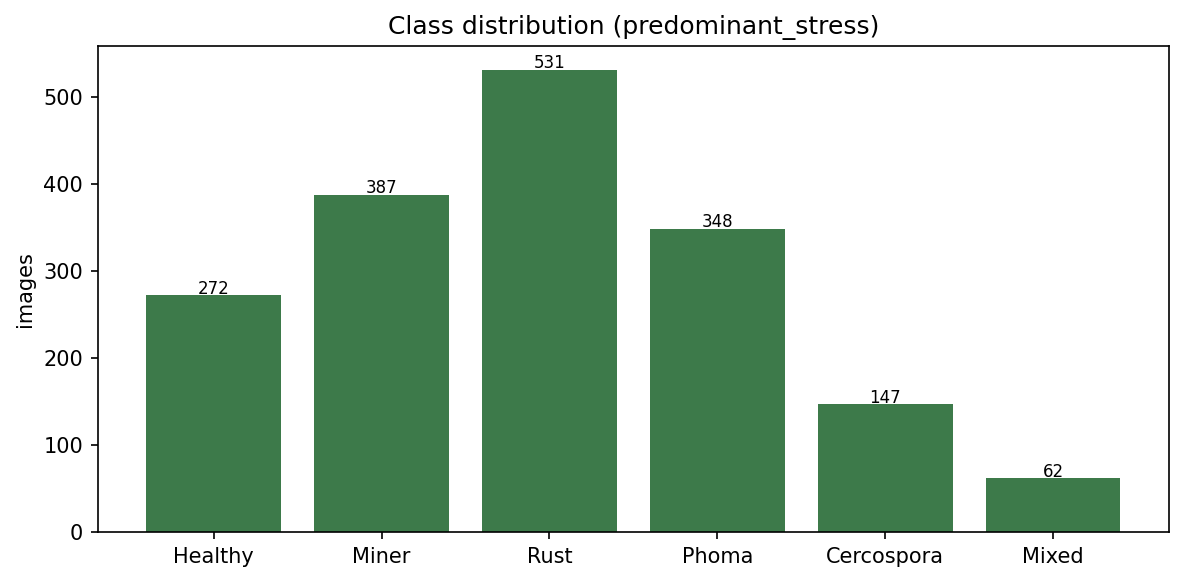

Saved class_distribution.png


In [3]:
counts = dataset.class_counts()
fig, ax = plt.subplots(figsize=(8, 4))
names = [STRESS_NAMES.get(int(i), str(i)) for i in counts.index]
ax.bar(names, counts.values, color="#3d7a4a")
ax.set_ylabel("images")
ax.set_title("Class distribution (predominant_stress)")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(int(v)), ha="center", fontsize=8)
fig.tight_layout()
save_and_show(fig, "class_distribution.png", PATHS["figures_dir"])
print("Saved class_distribution.png")


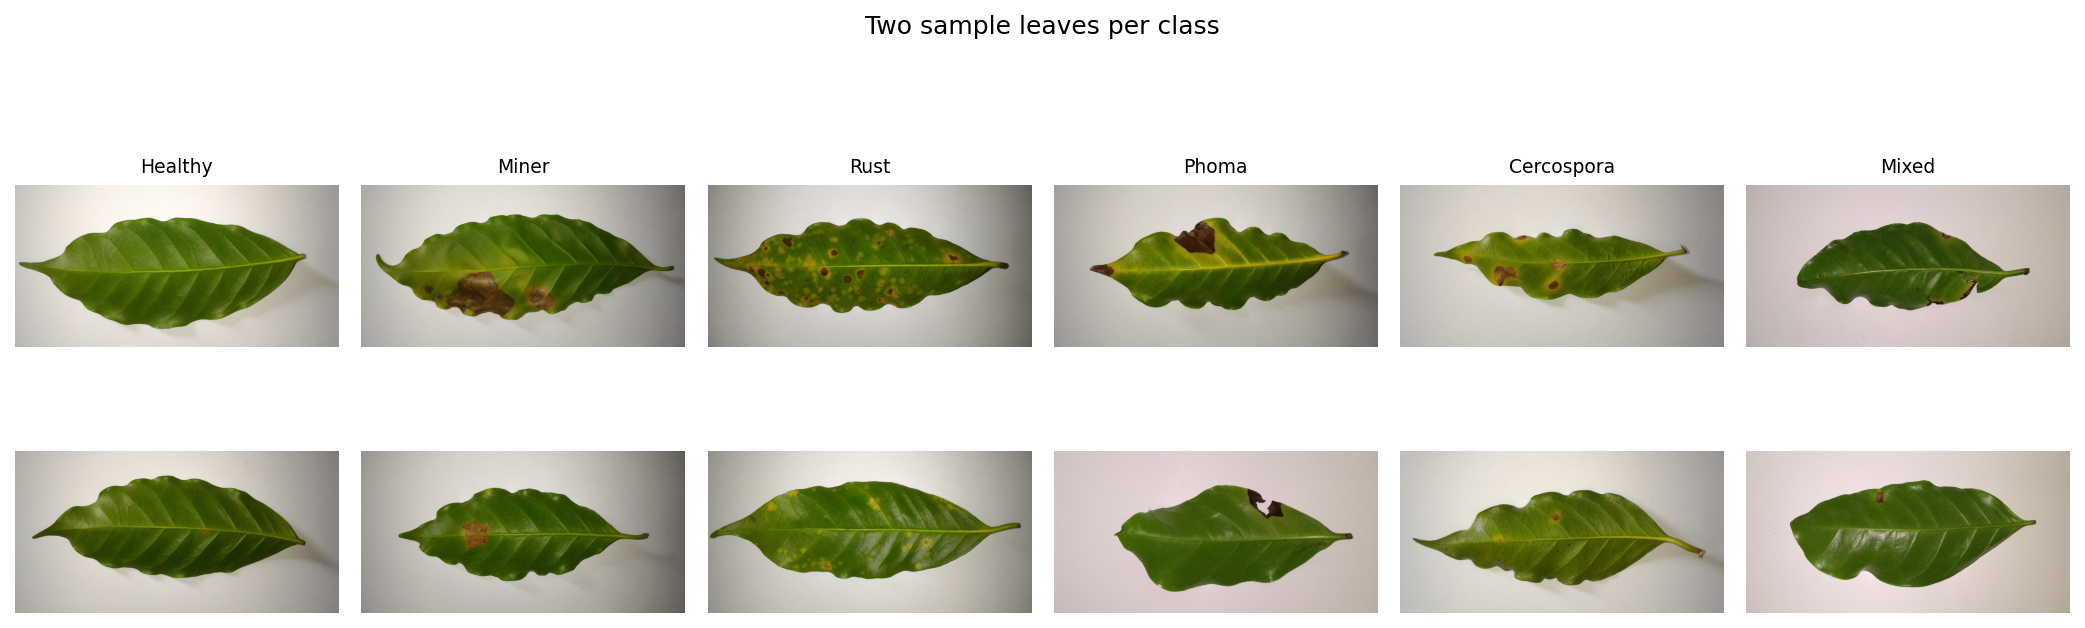

'/mnt/c/Users/Alecs/PML/Project_1/figures/sample_images.png'

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col, label in enumerate(sorted(df["predominant_stress"].unique())):
    sub = df[df["predominant_stress"] == label]
    for row in range(2):
        ax = axes[row, col]
        sample = sub.iloc[row % len(sub)]
        img = plt.imread(sample["image_path"])
        ax.imshow(img)
        ax.axis("off")
        if row == 0:
            ax.set_title(STRESS_NAMES.get(int(label), str(label)), fontsize=9)
fig.suptitle("Two sample leaves per class")
fig.tight_layout()
save_and_show(fig, "sample_images.png", PATHS["figures_dir"])


In [5]:
from PIL import Image as PILImage

with PILImage.open(df["image_path"].iloc[0]) as im:
    w, h = im.size
print(f"Native size: {w} x {h}. All current leaf JPEGs share this size; the models resize to 224 x 224.")


Native size: 2048 x 1024. All current leaf JPEGs share this size; the models resize to 224 x 224.


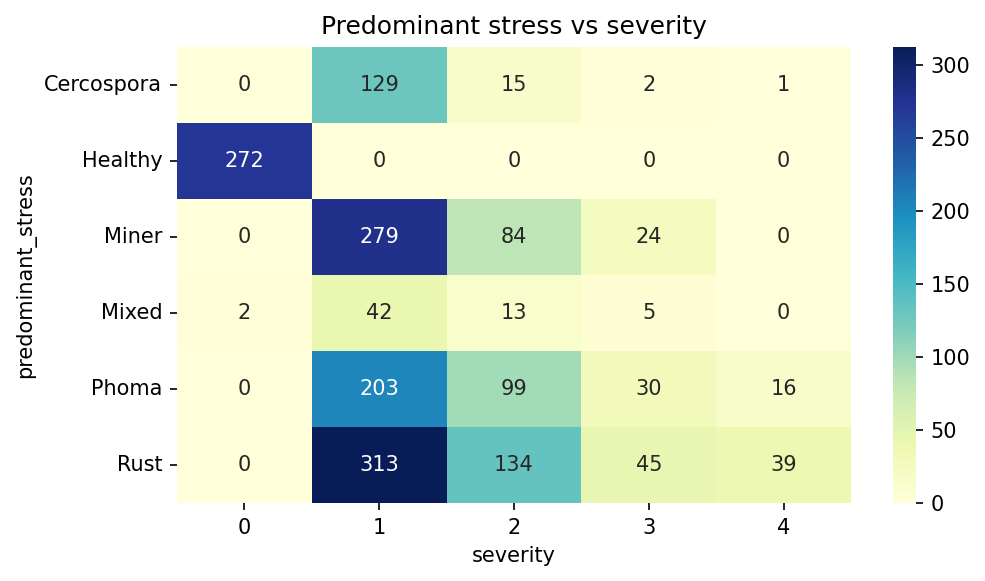

'/mnt/c/Users/Alecs/PML/Project_1/figures/eda_heatmaps.png'

In [6]:
ct = pd.crosstab(df["predominant_stress"].map(STRESS_NAMES), df["severity"])
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(ct, annot=True, fmt="d", cmap="YlGnBu", ax=ax)
ax.set_title("Predominant stress vs severity")
fig.tight_layout()
save_and_show(fig, "eda_heatmaps.png", PATHS["figures_dir"])


A perceptual-hash scan on the current leaf files found no duplicate groups, so that check is omitted from the run.


## 4. Train / validation / test split (criterion h)

Stratified 70 / 15 / 15. The same indices are saved and reused by every model. Hyperparameters are chosen on validation only. Test is used once, after the config is locked.


In [7]:
split_path = os.path.join(PATHS["features_dir"], "split_ids.npz")
# Reuse the saved split when it covers every kept row. Rebuild (and drop feature
# caches) only if the filtered table changed.
split = None
if os.path.exists(split_path):
    split = TrainValTestSplit.load(split_path)
    n_split = len(split.train_idx) + len(split.val_idx) + len(split.test_idx)
    if n_split != len(dataset.frame):
        print(f"Split has {n_split} rows, dataset has {len(dataset.frame)}; rebuilding.")
        os.remove(split_path)
        split = None
        for fname in ("handcrafted.npz", "frozen_deep.npz"):
            p = os.path.join(PATHS["features_dir"], fname)
            if os.path.isfile(p):
                os.remove(p)
                print("Deleted stale feature cache:", p)
if split is None:
    split = TrainValTestSplit.make(dataset, seed=RANDOM_STATE, path=split_path)
split.assert_disjoint()
print("Sizes:", split.sizes())

for name, idx in [("train", split.train_idx), ("val", split.val_idx), ("test", split.test_idx)]:
    dist = df.iloc[idx]["predominant_stress"].value_counts(normalize=True).sort_index()
    print(name, {STRESS_NAMES[int(k)]: round(float(v), 3) for k, v in dist.items()})


Sizes: {'train': 1222, 'val': 262, 'test': 263}
train {'Healthy': 0.155, 'Miner': 0.222, 'Rust': 0.304, 'Phoma': 0.199, 'Cercospora': 0.084, 'Mixed': 0.036}
val {'Healthy': 0.156, 'Miner': 0.221, 'Rust': 0.305, 'Phoma': 0.198, 'Cercospora': 0.084, 'Mixed': 0.034}
test {'Healthy': 0.156, 'Miner': 0.221, 'Rust': 0.304, 'Phoma': 0.202, 'Cercospora': 0.084, 'Mixed': 0.034}


## 5. FE1 — Handcrafted features (criterion c)

White-background mask, then HSV histogram (512), uniform LBP (26), HOG on 224×224 with 16×16 cells. Concatenate and L2-normalise. Cache to disk.


In [8]:
hc_path = os.path.join(PATHS["features_dir"], "handcrafted.npz")
fe1 = HandcraftedFeatures(hc_path, image_size=224)
pack_hc = fe1.extract(dataset, split)
print("Handcrafted shapes:", pack_hc.X_train.shape, pack_hc.X_val.shape, pack_hc.X_test.shape)


Handcrafted shapes: (1222, 26782) (262, 26782) (262, 26782)


## 6. FE2 — Frozen EfficientNet embeddings (criterion c)

ImageNet EfficientNet-B0 without the classifier, global average pooling, 1280 numbers per image. No augmentation at extract time.


In [9]:
deep_path = os.path.join(PATHS["features_dir"], "frozen_deep.npz")
fe2 = FrozenDeepFeatures(deep_path, input_size=224, batch_size=32)
pack_deep = fe2.extract(dataset, split)
print("Deep shapes:", pack_deep.X_train.shape, pack_deep.X_val.shape, pack_deep.X_test.shape)


Deep shapes: (1222, 1280) (262, 1280) (262, 1280)


## 7. FE3 — PCA on frozen embeddings (optional SVM axis)

PCA is fit on the **train** embeddings only, then applied to val and test.


In [10]:
fe3 = PCAFeatures(n_components=256, source=pack_deep)
pack_pca = fe3.extract(dataset, split)
print("PCA shapes:", pack_pca.X_train.shape, "explained variance ratio sum:",
      float(fe3.pca.explained_variance_ratio_.sum()))


PCA shapes: (1222, 256) explained variance ratio sum: 0.9618242979049683


## 8. Model 1 — SVM, full grading loop

Personalized ingest: `StandardScaler` on train only. Then fit a default RBF SVM, search C × gamma on **validation** accuracy (plus a linear kernel sweep), refit the winner, report test once.

We run the loop twice: handcrafted features, then frozen deep features.


In [11]:
# One row per (model, features). A list would duplicate if you re-run a pipeline cell.
# A set of dicts is not possible (dicts are unhashable); a dict keyed by that pair upserts.
results_by_key = {}

def record(model_name, features, pipe=None, **extra):
    if pipe is not None:
        row = {
            "model": model_name,
            "features": features,
            "val_acc": pipe.val_metrics.get("acc"),
            "test_acc": pipe.test_metrics.get("acc"),
            "macro_f1": pipe.test_metrics.get("macro_f1"),
            "best_params": pipe.best_params,
        }
    else:
        row = {"model": model_name, "features": features}
        row.update(extra)
    results_by_key[(model_name, features)] = row
    print(row)

def results_rows():
    return list(results_by_key.values())


[svm_handcrafted] start  train=1222 x 26782  search=12 RBF + 4 linear  proba=False


[svm_handcrafted] ingest  scaling 1222 x 26782  elapsed 0:00


[svm_handcrafted] ingest  done in 0:00  elapsed 0:00


[svm_handcrafted] fit  default RBF C=1 gamma=scale  elapsed 0:00


[svm_handcrafted] fit  done in 8:21  val_acc=0.592  elapsed 8:21


...

[svm_handcrafted] search  13/16  linear C=0.1 gamma=scale  val_acc=0.645  1:30  remaining ~20:06  elapsed 1:35:27


[svm_handcrafted] search  14/16  linear C=1 gamma=scale  val_acc=0.645  1:03  remaining ~12:36  elapsed 1:36:30


[svm_handcrafted] search  15/16  linear C=10 gamma=scale  val_acc=0.645  1:15  remaining ~5:58  elapsed 1:37:45


[svm_handcrafted] search  16/16  linear C=100 gamma=scale  val_acc=0.645  1:17  remaining ~0:00  elapsed 1:39:02


[svm_handcrafted] search  done  best={'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}  val_acc=0.645  elapsed 1:39:02


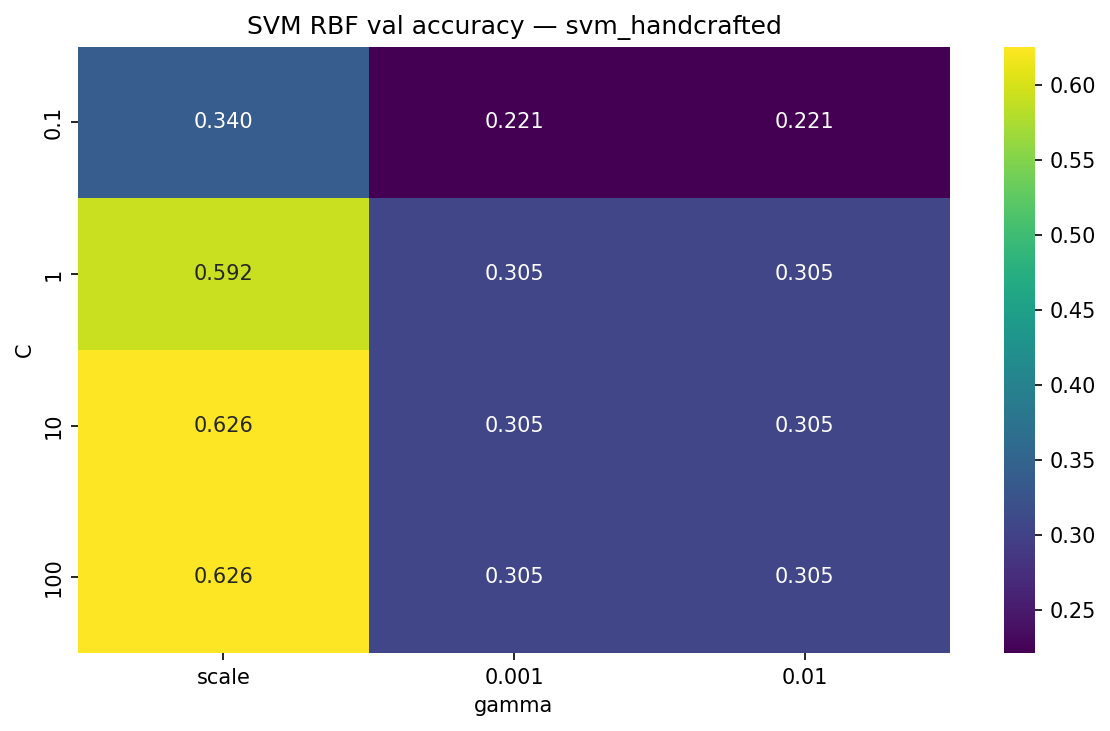

[svm_handcrafted] refit  linear C=0.1 gamma=scale  proba=False  elapsed 1:39:02


[svm_handcrafted] refit  done in 1:35  elapsed 1:40:37


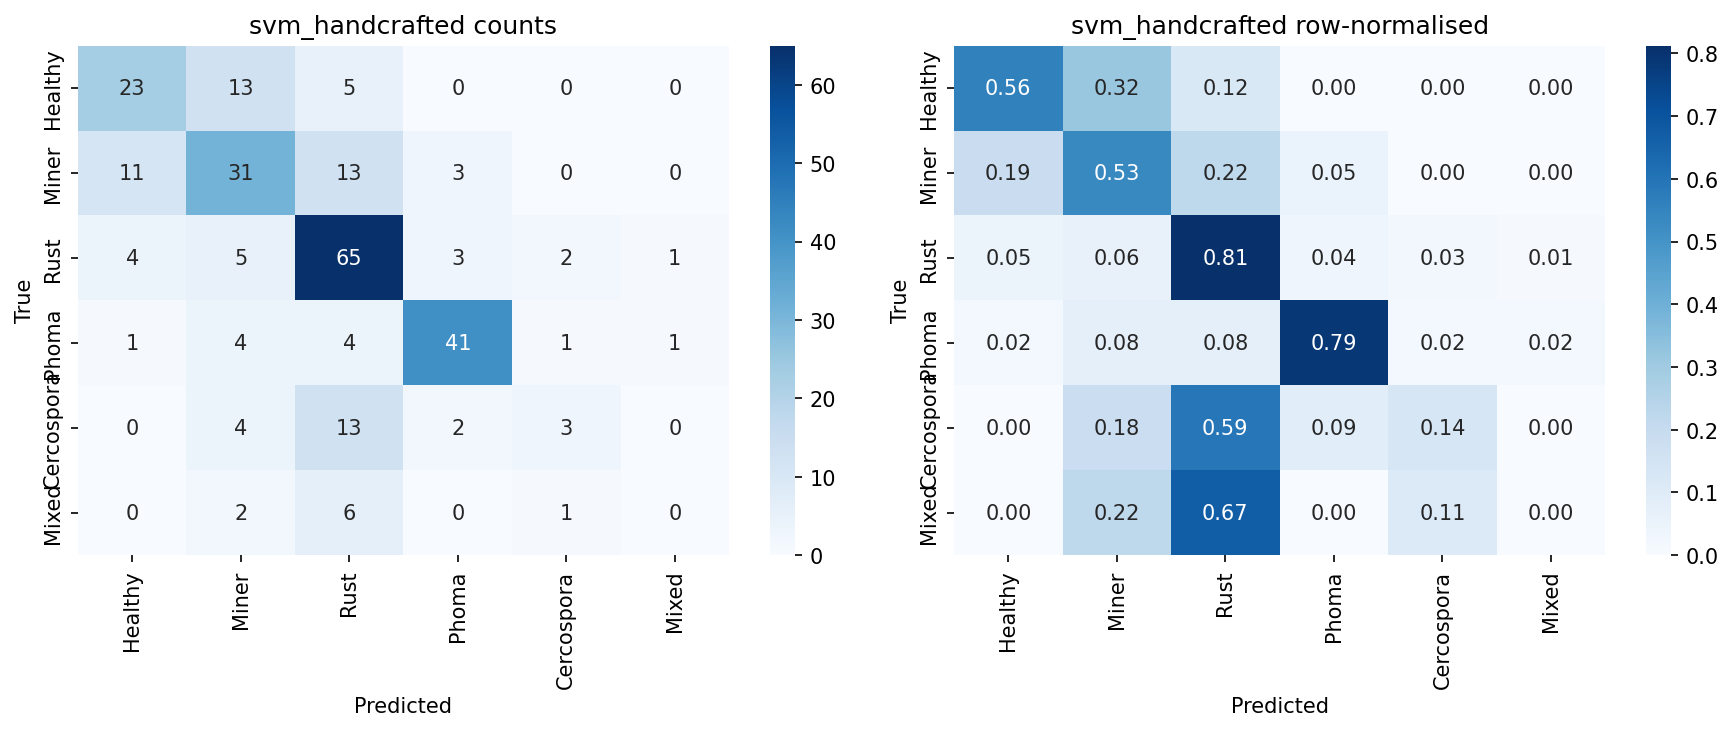

[svm_handcrafted] total 1:40:37


{'model': 'SVM', 'features': 'handcrafted', 'val_acc': 0.6450381679389313, 'test_acc': 0.6221374045801527, 'macro_f1': 0.47043616682337924, 'best_params': {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}}
{'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}


In [12]:
svm_hc = SVMPipeline(
    pack_hc, name="svm_handcrafted",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=False,
    C_grid=[0.1, 1, 10, 100],
    gamma_grid=["scale"],
    search_linear_first=True,
    skip_default_fit=True,
)
svm_hc.run()
record("SVM", "handcrafted", svm_hc)
print(svm_hc.best_params)


[svm_deep] start  train=1222 x 1280  search=25 RBF + 5 linear  proba=True


[svm_deep] ingest  scaling 1222 x 1280  elapsed 0:00


[svm_deep] ingest  done in 0:00  elapsed 0:00


[svm_deep] fit  default RBF C=1 gamma=scale  elapsed 0:00


[svm_deep] fit  done in 0:00  val_acc=0.790  elapsed 0:00


...

[svm_deep] search  27/30  linear C=1 gamma=scale  val_acc=0.821  0:00  remaining ~0:01  elapsed 0:10


[svm_deep] search  28/30  linear C=10 gamma=scale  val_acc=0.821  0:00  remaining ~0:01  elapsed 0:10


[svm_deep] search  29/30  linear C=100 gamma=scale  val_acc=0.821  0:00  remaining ~0:00  elapsed 0:11


[svm_deep] search  30/30  linear C=1000 gamma=scale  val_acc=0.821  0:00  remaining ~0:00  elapsed 0:11


[svm_deep] search  done  best={'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}  val_acc=0.828  elapsed 0:11


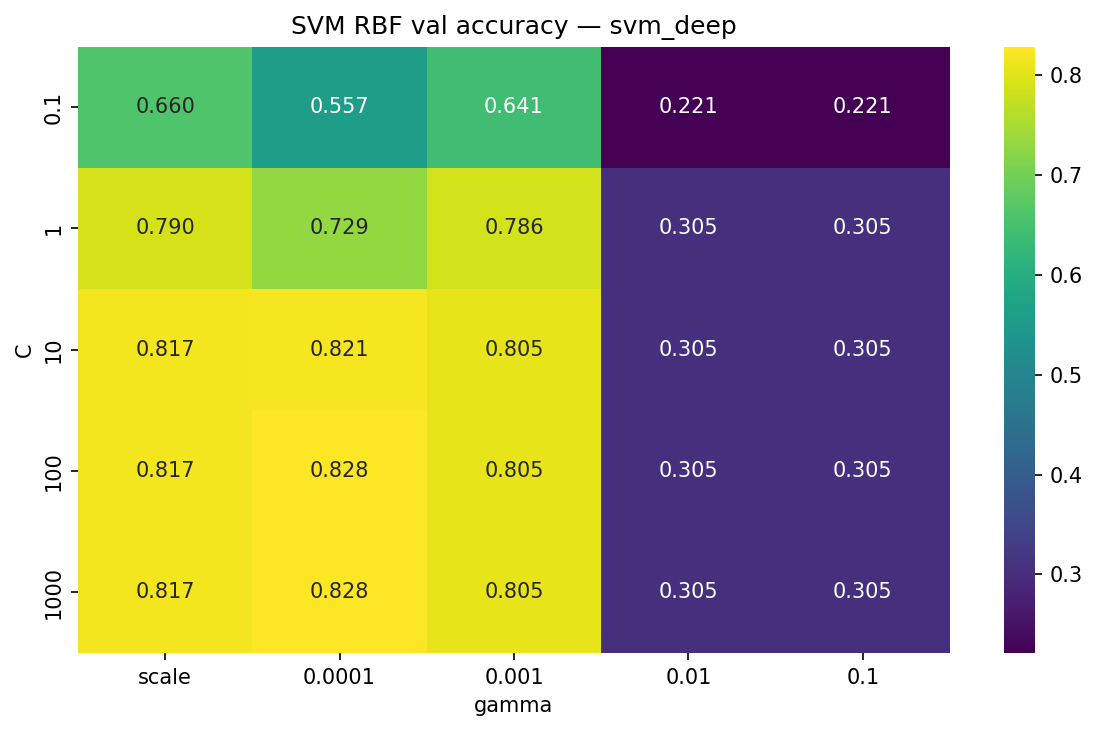

[svm_deep] refit  rbf C=100 gamma=0.0001  proba=True  elapsed 0:11


[svm_deep] refit  done in 0:01  elapsed 0:12


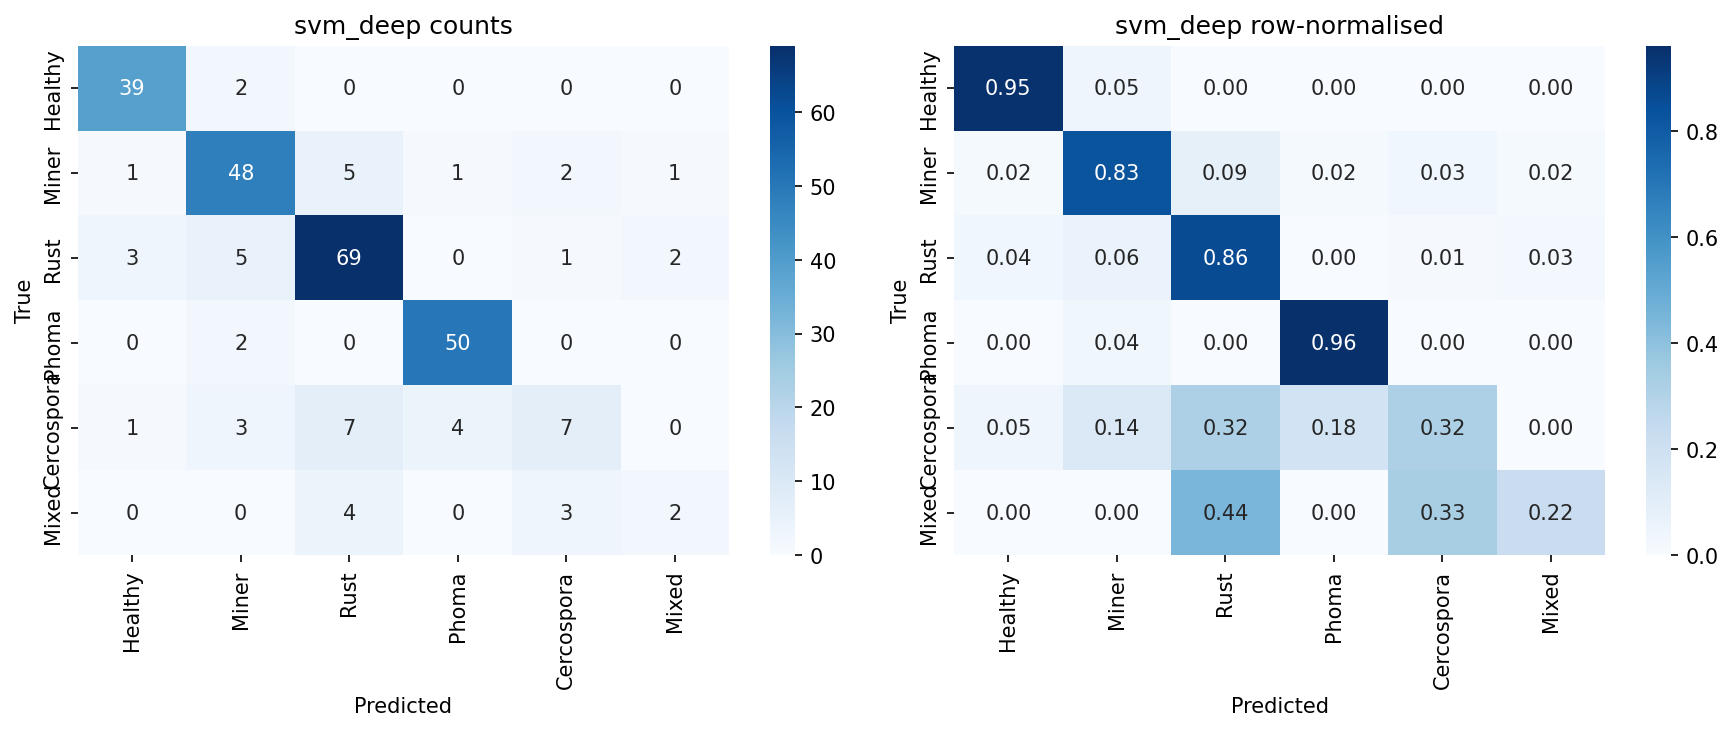

[svm_deep] total 0:12


{'model': 'SVM', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8282442748091603, 'test_acc': 0.8206106870229007, 'macro_f1': 0.6979772903646144, 'best_params': {'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}}
{'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}


In [13]:
svm_deep = SVMPipeline(
    pack_deep, name="svm_deep",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=True,
)
svm_deep.run()
record("SVM", "deep (frozen EffNet)", svm_deep)
print(svm_deep.best_params)


Best linear SVM on deep features (val): {'kernel': 'linear', 'C': 0.1, 'gamma': None, 'val_acc': 0.8206106870229007}
{'model': 'SVM-linear (ablation)', 'features': 'deep (frozen EffNet)', 'val_acc': 0.8206106870229007, 'test_acc': 0.8053435114503816, 'macro_f1': 0.6837798205773922, 'best_params': {'kernel': 'linear', 'C': 0.1}}


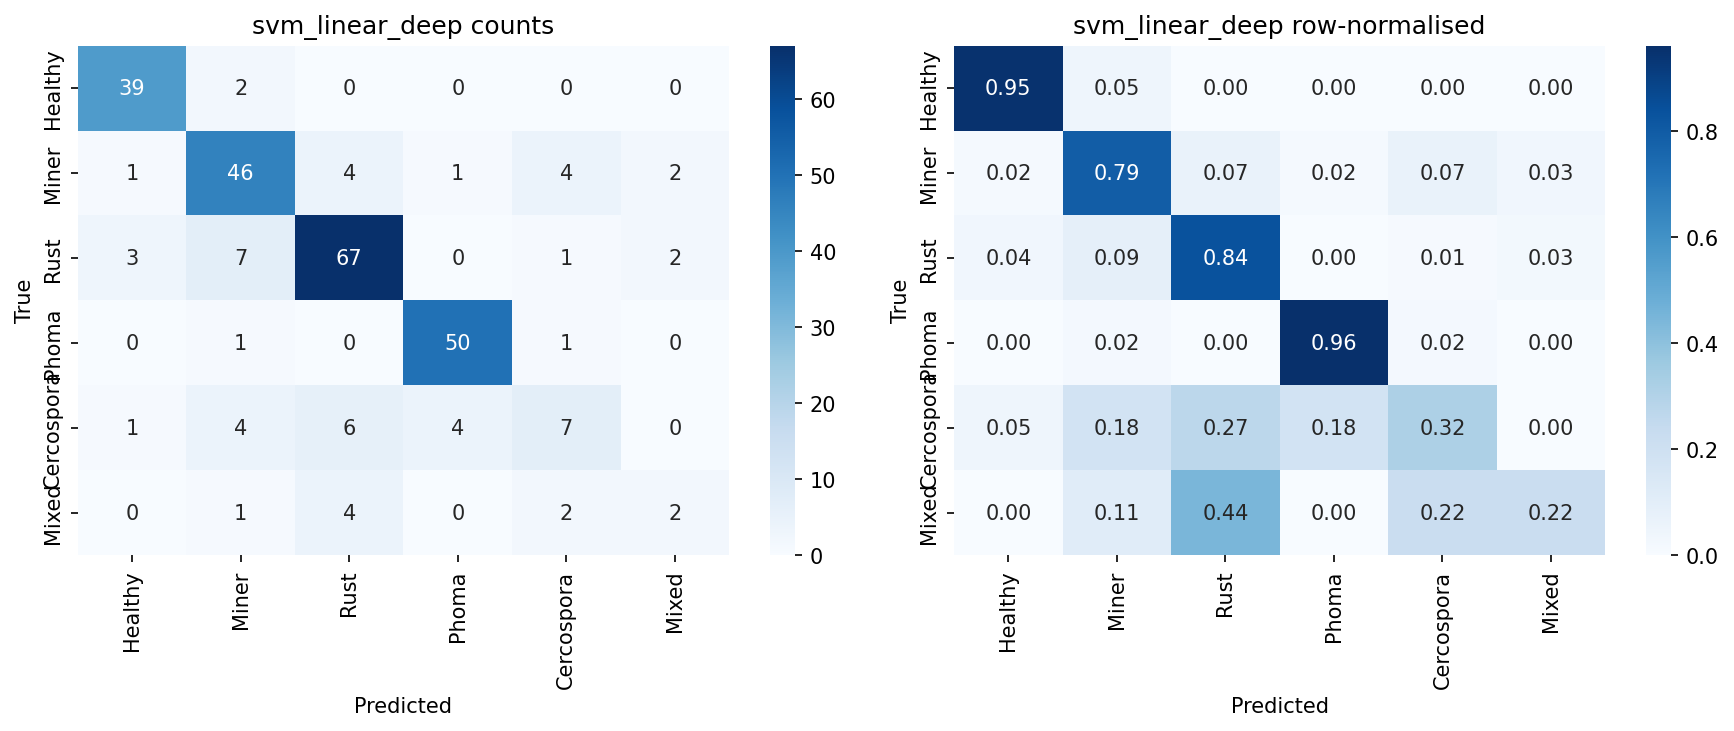

{'acc': 0.8053435114503816,
 'macro_f1': 0.6837798205773922,
 'weighted_f1': 0.7953059986387074,
 'macro_precision': 0.6961188999895739,
 'macro_recall': 0.6806275770689143}

In [14]:
# Linear kernel on deep features is already part of search(); pick the best linear row for a dedicated report.
linear_rows = [r for r in svm_deep.search_table if r["kernel"] == "linear"]
best_linear = max(linear_rows, key=lambda r: r["val_acc"])
print("Best linear SVM on deep features (val):", best_linear)

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

scaled_deep, _ = scale_pack(pack_deep)
lin = SVC(kernel="linear", C=best_linear["C"], class_weight="balanced")
lin.fit(scaled_deep.X_train, scaled_deep.y_train)
pred_lin = lin.predict(scaled_deep.X_test)
pred_lin_val = lin.predict(scaled_deep.X_val)
record(
    "SVM-linear (ablation)",
    "deep (frozen EffNet)",
    val_acc=float(accuracy_score(scaled_deep.y_val, pred_lin_val)),
    test_acc=float(accuracy_score(scaled_deep.y_test, pred_lin)),
    macro_f1=float(f1_score(scaled_deep.y_test, pred_lin, average="macro", zero_division=0)),
    best_params={"kernel": "linear", "C": best_linear["C"]},
)
svm_deep.report(scaled_deep.y_test, pred_lin, "svm_linear_deep")


Optional PCA pack for SVM. Same loop, smaller vectors. Useful if the 1280-d RBF grid is slow.


[svm_pca256] start  train=1222 x 256  search=25 RBF + 5 linear  proba=False


[svm_pca256] ingest  scaling 1222 x 256  elapsed 0:00


[svm_pca256] ingest  done in 0:00  elapsed 0:00


[svm_pca256] fit  default RBF C=1 gamma=scale  elapsed 0:00


[svm_pca256] fit  done in 0:00  val_acc=0.782  elapsed 0:00


...

[svm_pca256] search  27/30  linear C=1 gamma=scale  val_acc=0.767  0:00  remaining ~0:00  elapsed 0:04


[svm_pca256] search  28/30  linear C=10 gamma=scale  val_acc=0.767  0:00  remaining ~0:00  elapsed 0:04


[svm_pca256] search  29/30  linear C=100 gamma=scale  val_acc=0.767  0:00  remaining ~0:00  elapsed 0:04


[svm_pca256] search  30/30  linear C=1000 gamma=scale  val_acc=0.767  0:00  remaining ~0:00  elapsed 0:05


[svm_pca256] search  done  best={'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}  val_acc=0.798  elapsed 0:05


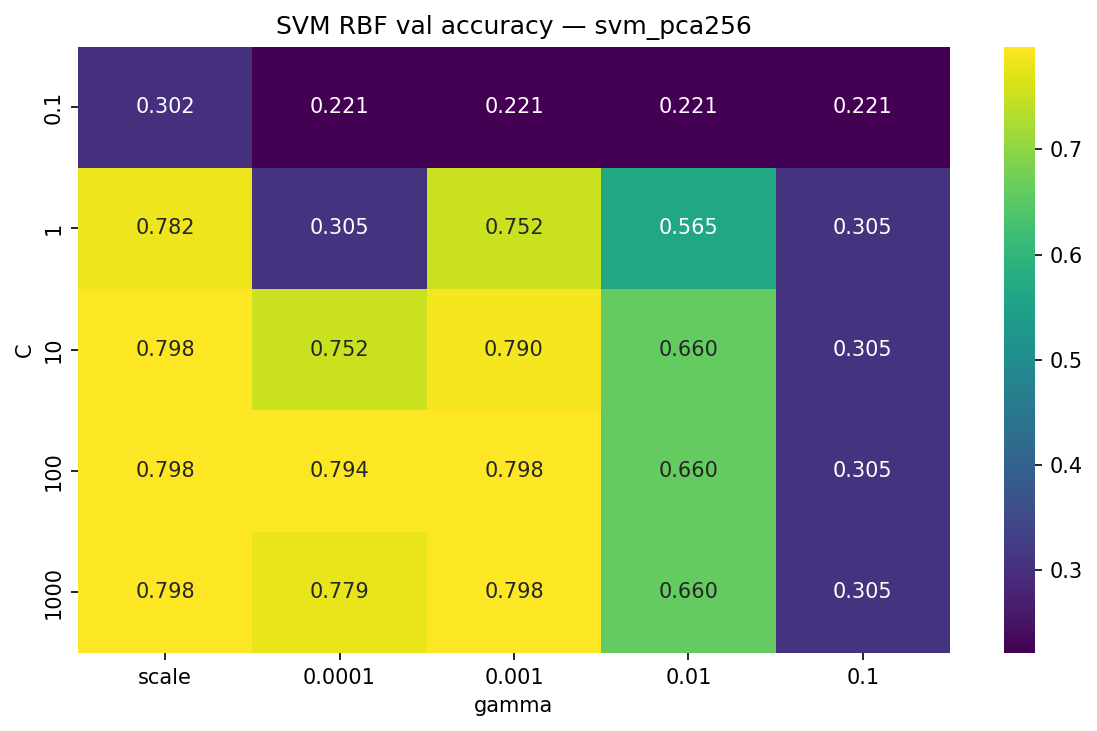

[svm_pca256] refit  rbf C=10 gamma=scale  proba=False  elapsed 0:05


[svm_pca256] refit  done in 0:00  elapsed 0:05


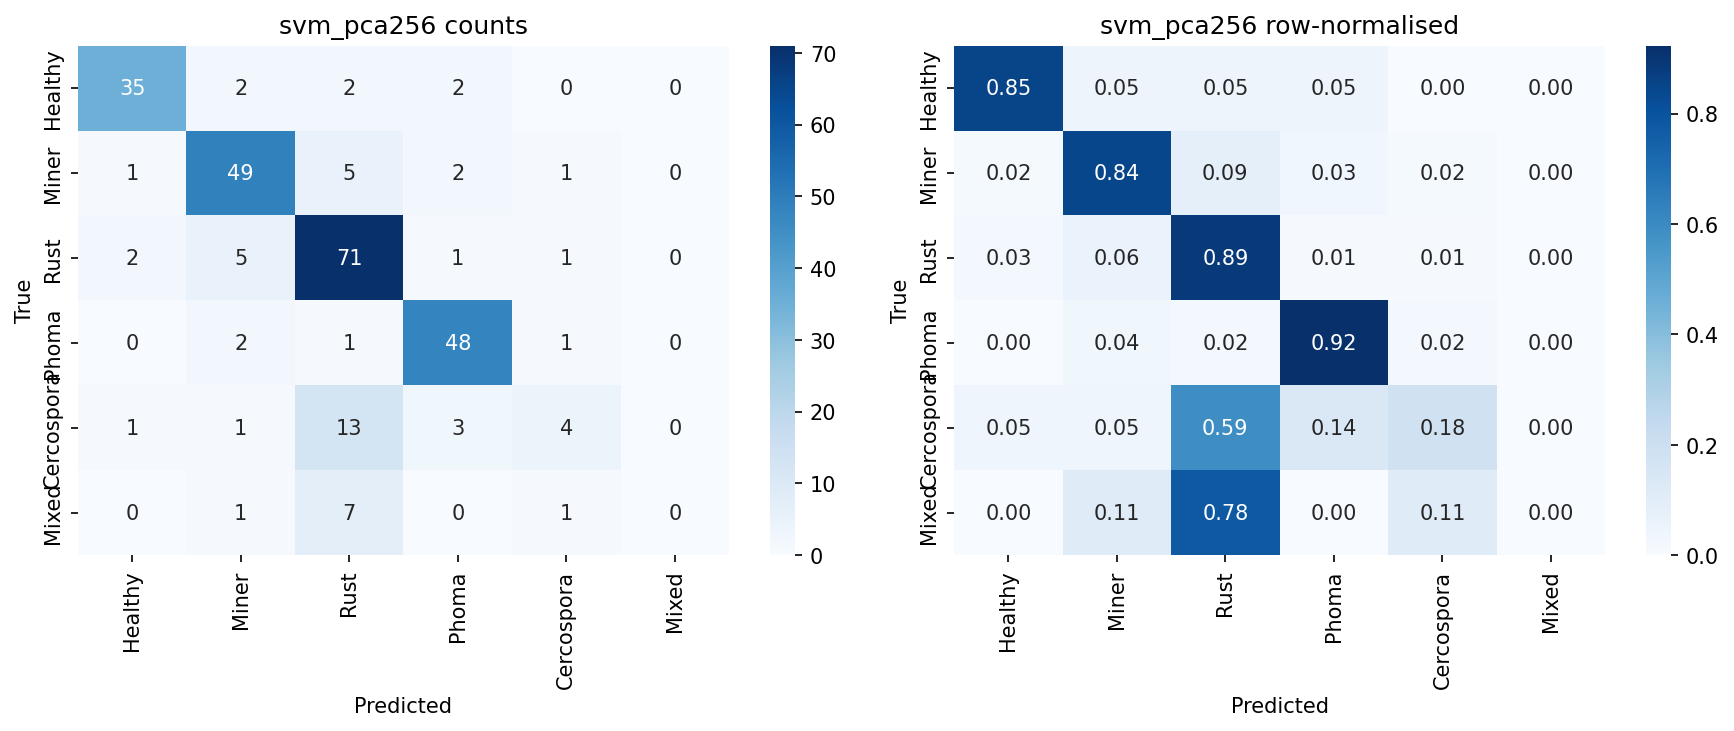

[svm_pca256] total 0:05


{'model': 'SVM', 'features': 'deep PCA-256', 'val_acc': 0.7977099236641222, 'test_acc': 0.7900763358778626, 'macro_f1': 0.6090600199195503, 'best_params': {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}}


In [15]:
svm_pca = SVMPipeline(
    pack_pca, name="svm_pca256",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
    need_proba=False,
)
svm_pca.run()
record("SVM", "deep PCA-256", svm_pca)


### Model 1 literature note

Margin classifiers on frozen CNN embeddings are a standard transfer-learning probe. We are not copying Esgario's protocol here: they fine-tune ResNet-50 on pixels. The SVM numbers answer a different question: how much of the disease signal is already in ImageNet features.


## 9. Model 2 — EfficientNet-B0, full grading loop

Personalized ingest: raw 224×224 RGB. MixUp plus flips. Phase 1 trains the head with a frozen backbone. Phase 2 opens the last layers at a lower learning rate. Early stopping watches validation loss. Test is scored once after search.


2026-08-27 20:31:47.543066: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-27 20:31:47.997251: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-27 20:31:50.186443: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787851912.271409  494319 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5518 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:65:00.0, compute capability: 8.9


Epoch 1/12


2026-08-27 20:32:00.674486: I external/local_xla/xla/service/service.cc:163] XLA service 0x78eaa4013140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-27 20:32:00.674563: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070 Laptop GPU, Compute Capability 8.9


...


64/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7158 - loss: 1.3045


68/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7139 - loss: 1.3041


72/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7120 - loss: 1.3044


76/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7103 - loss: 1.3055


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.6784 - loss: 1.3254 - val_accuracy: 0.7252 - val_loss: 0.8503 - learning_rate: 2.5000e-06


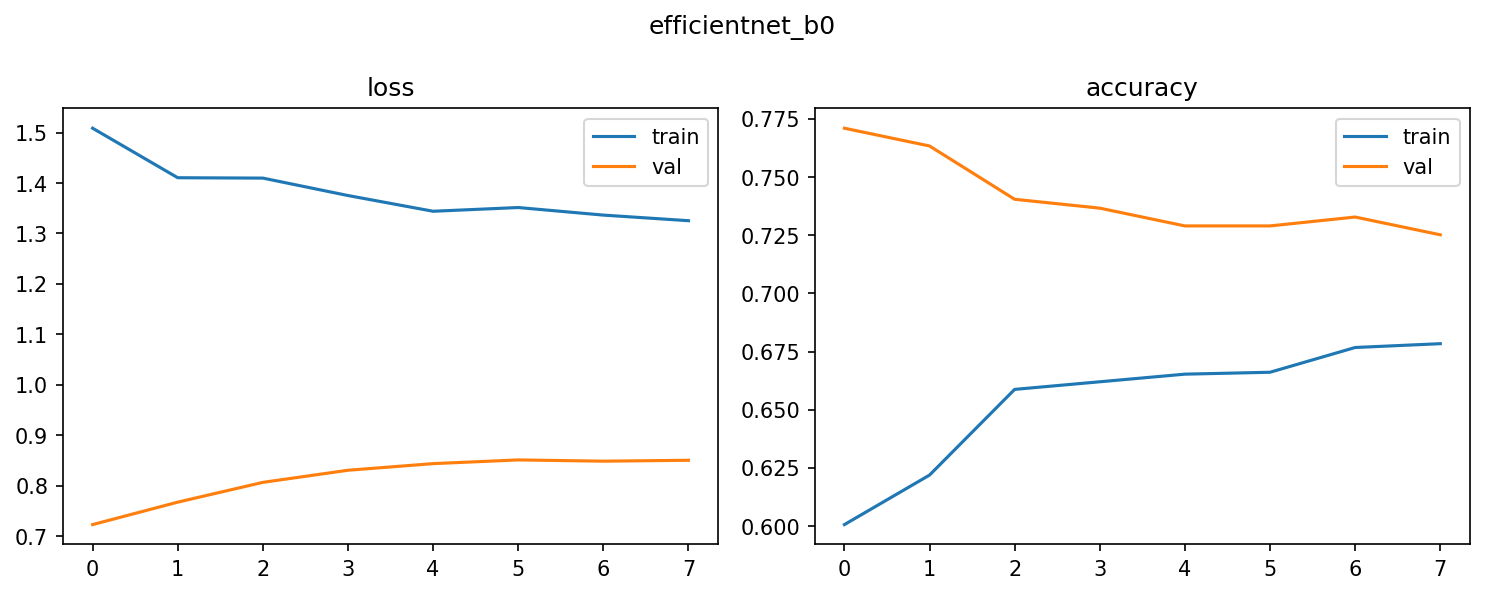

2026-08-27 20:33:47.002168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 20:33:47.190196: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:33:48.169532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:33:48.389007: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:33:49.021442: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:33:49.249629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


...


65/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6968 - loss: 1.3203


69/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6951 - loss: 1.3226


73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6935 - loss: 1.3241


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6921 - loss: 1.3246


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6661 - loss: 1.3349 - val_accuracy: 0.7328 - val_loss: 0.8264 - learning_rate: 2.5000e-06


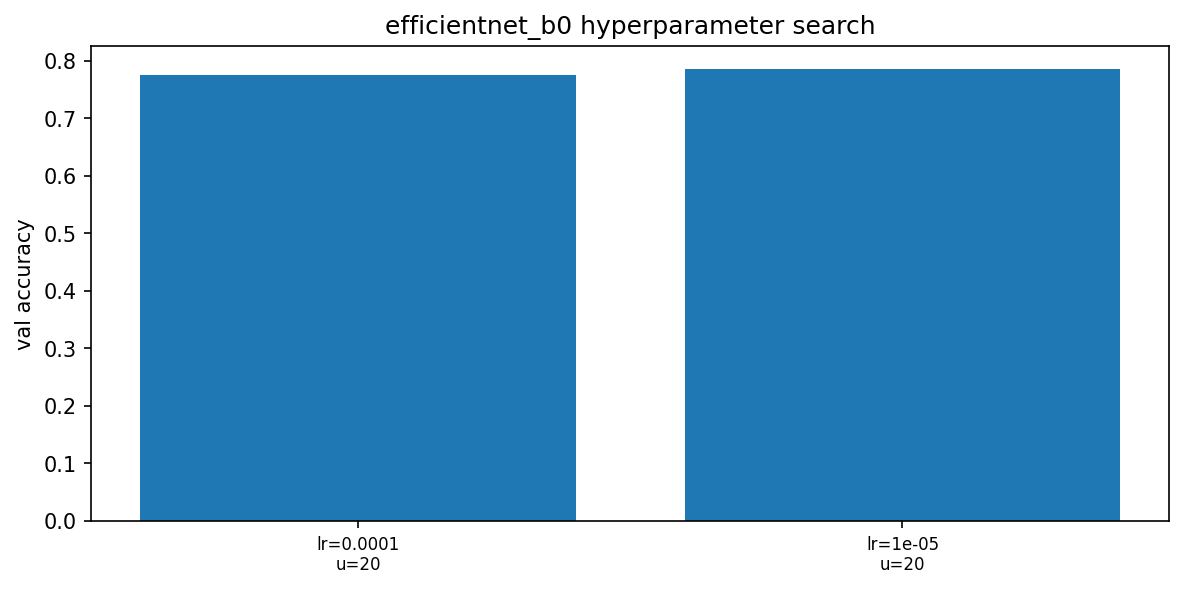

2026-08-27 20:37:06.382063: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 20:37:06.572065: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:37:07.240841: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:37:07.463697: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:37:07.684113: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:37:08.352042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2026-08-27 20:37:08.568188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


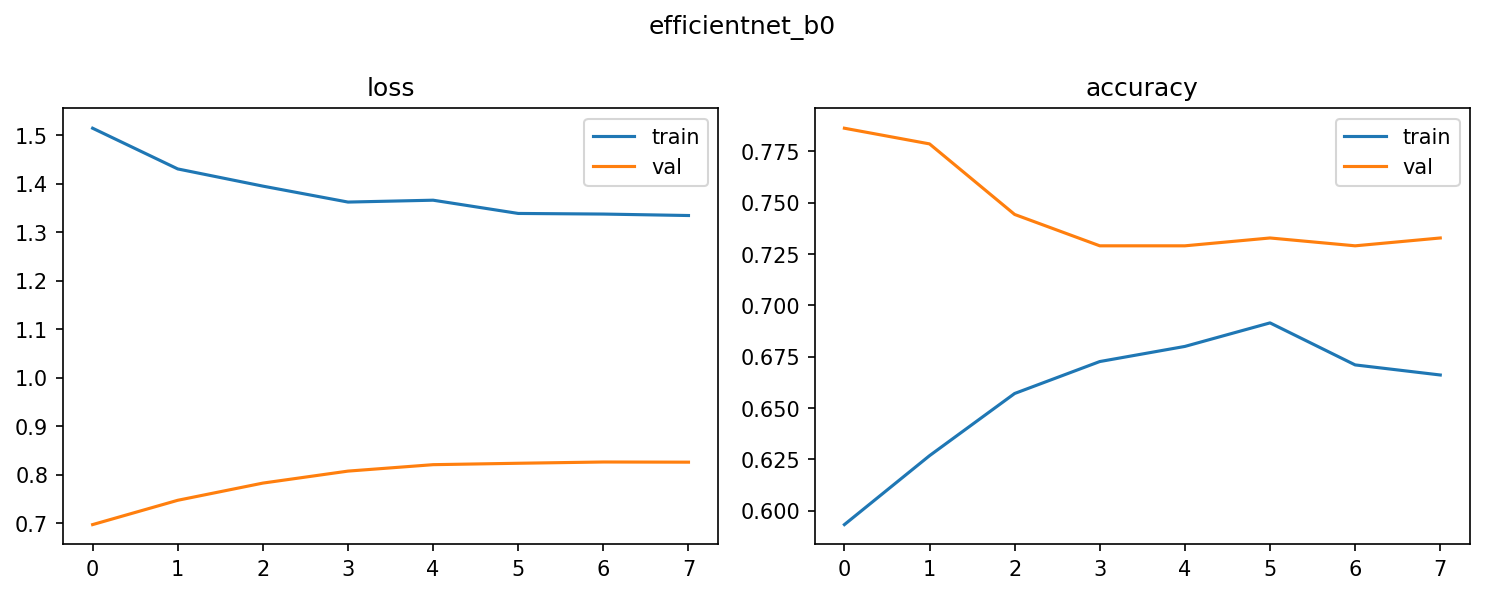

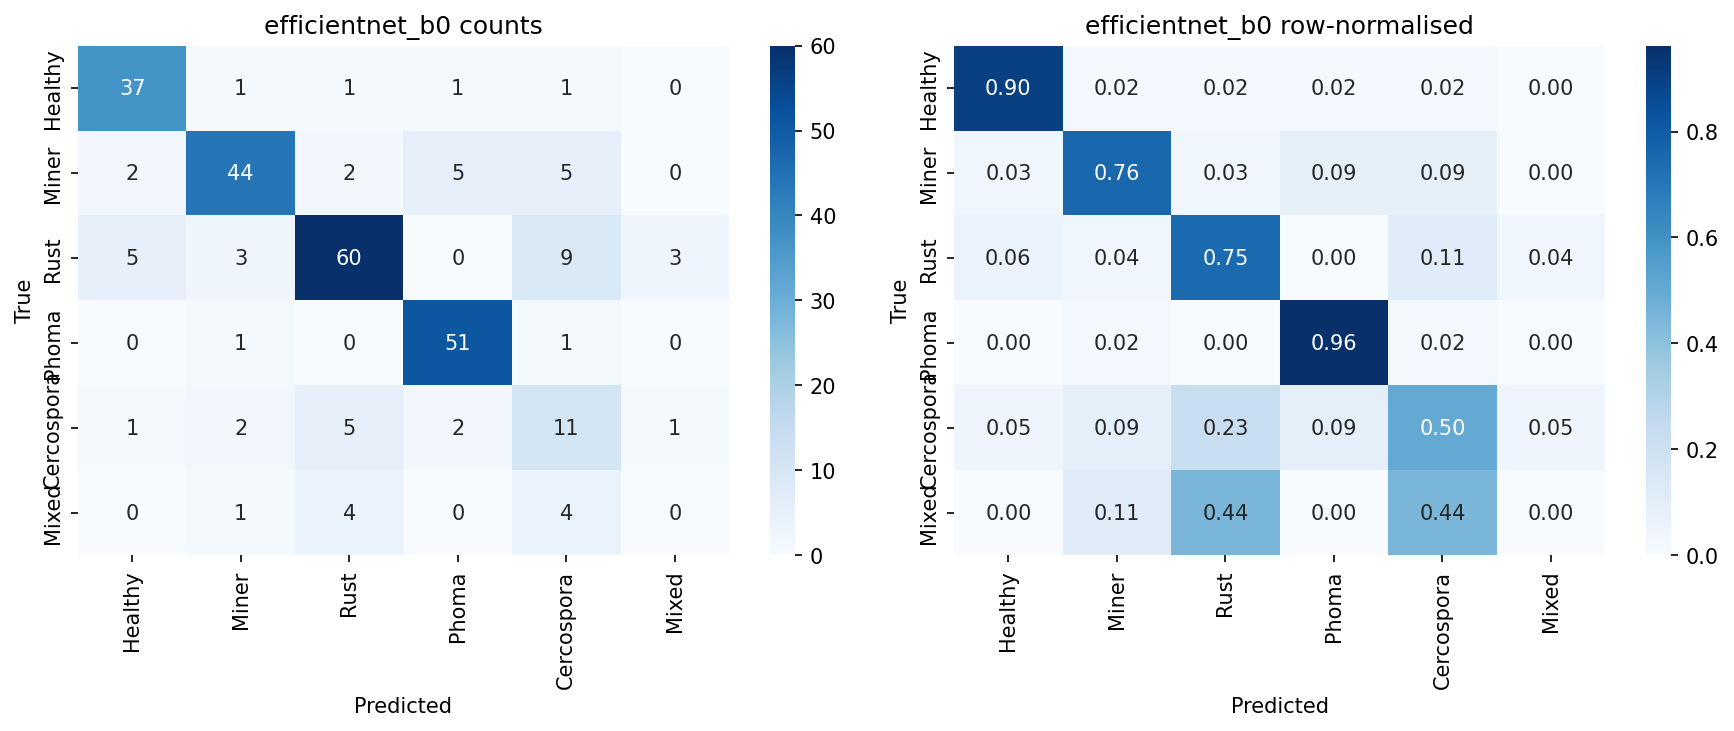

{'model': 'EfficientNet-B0', 'features': 'raw images', 'val_acc': 0.7862595419847328, 'test_acc': 0.7718631178707225, 'macro_f1': 0.6292912376377539, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}}
EffNet best params: {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}


In [16]:
# Keep the default grid small so the notebook can finish. Widen it if you have more GPU time.
effnet = EfficientNetPipeline(
    dataset, split,
    name="efficientnet_b0",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=True,
    ingest_hsv_crop=True,
    epochs_head=12,
    epochs_ft=20,
    batch_size=16,
    search_grid=[
        {"lr": 1e-4, "dropout": 0.3, "unfreeze": 20},
        {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20},
    ],
)
effnet.run()
record("EfficientNet-B0", "raw images", effnet)
print("EffNet best params:", effnet.best_params)


## 10. Extras (criterion i)


### 10.1 XGBoost on the same cached features


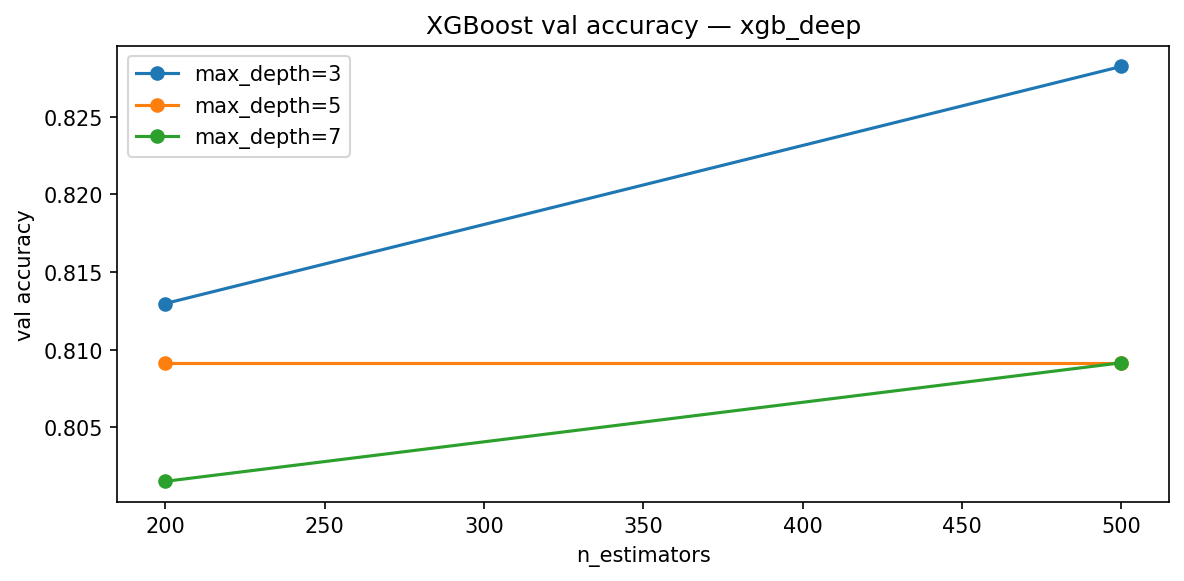

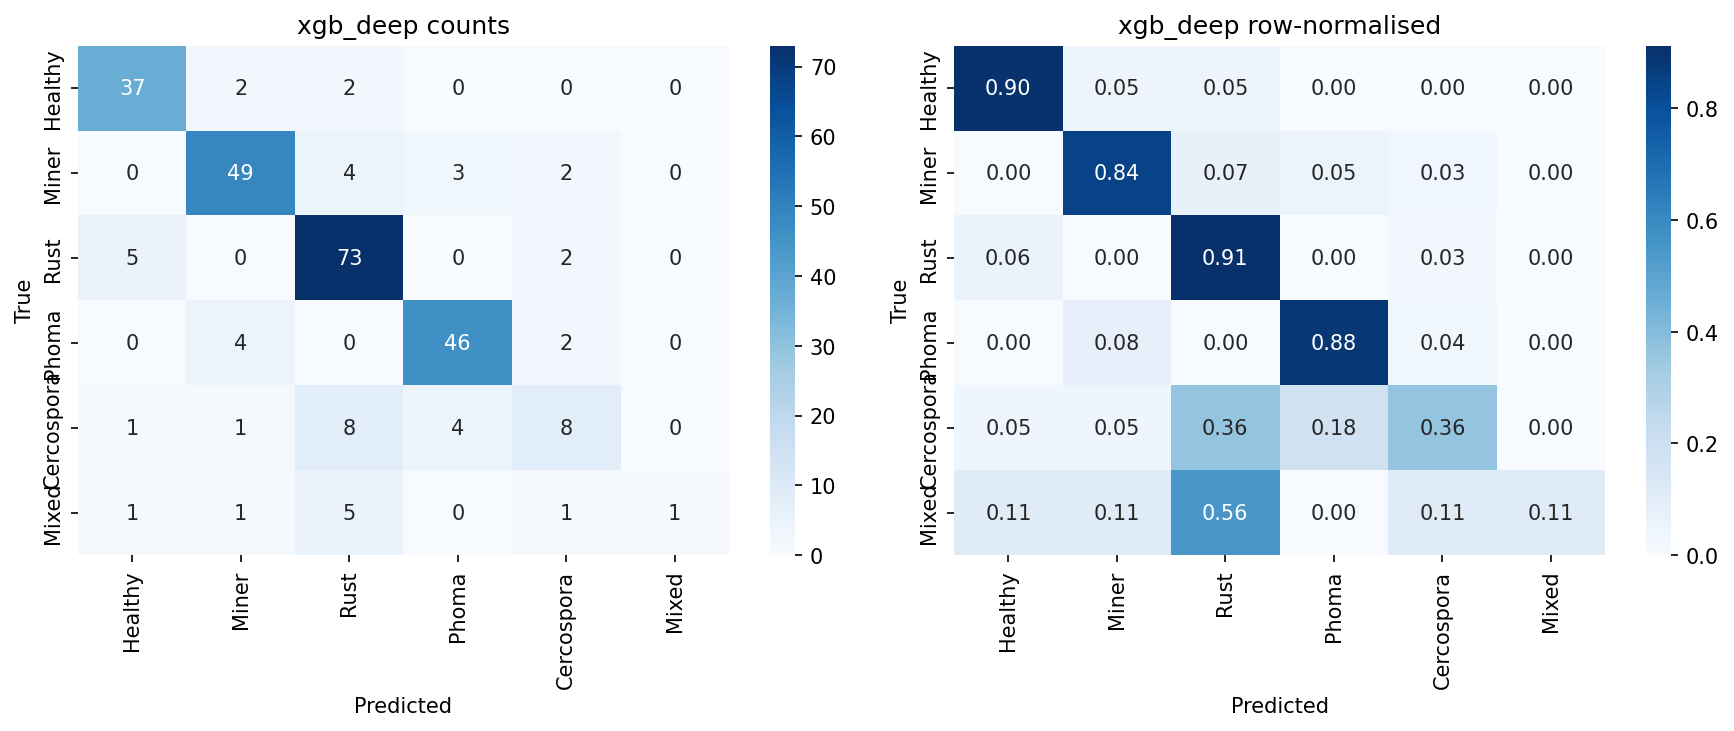

In [17]:
xgb_hc = XGBoostPipeline(
    pack_hc, name="xgb_handcrafted",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
)
xgb_hc.run()
record("XGBoost", "handcrafted", xgb_hc)

xgb_deep = XGBoostPipeline(
    pack_deep, name="xgb_deep",
    results_dir=PATHS["results_dir"], figures_dir=PATHS["figures_dir"],
)
xgb_deep.run()
record("XGBoost", "deep (frozen EffNet)", xgb_deep)


### 10.2 ResNet-50 (third method, same protocol as EfficientNet)


Epoch 1/10



 1/77 ━━━━━━━━━━━━━━━━━━━━ 13:03 10s/step - accuracy: 0.1250 - loss: 1.5982


 3/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.1806 - loss: 1.6791  


 5/77 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.1977 - loss: 1.7686


 7/77 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.1988 - loss: 1.8221

...


71/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9800 - loss: 0.1396


73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9800 - loss: 0.1394


75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9800 - loss: 0.1393


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9800 - loss: 0.1392


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.9795 - loss: 0.1335 - val_accuracy: 0.7977 - val_loss: 0.6578 - learning_rate: 5.0000e-06


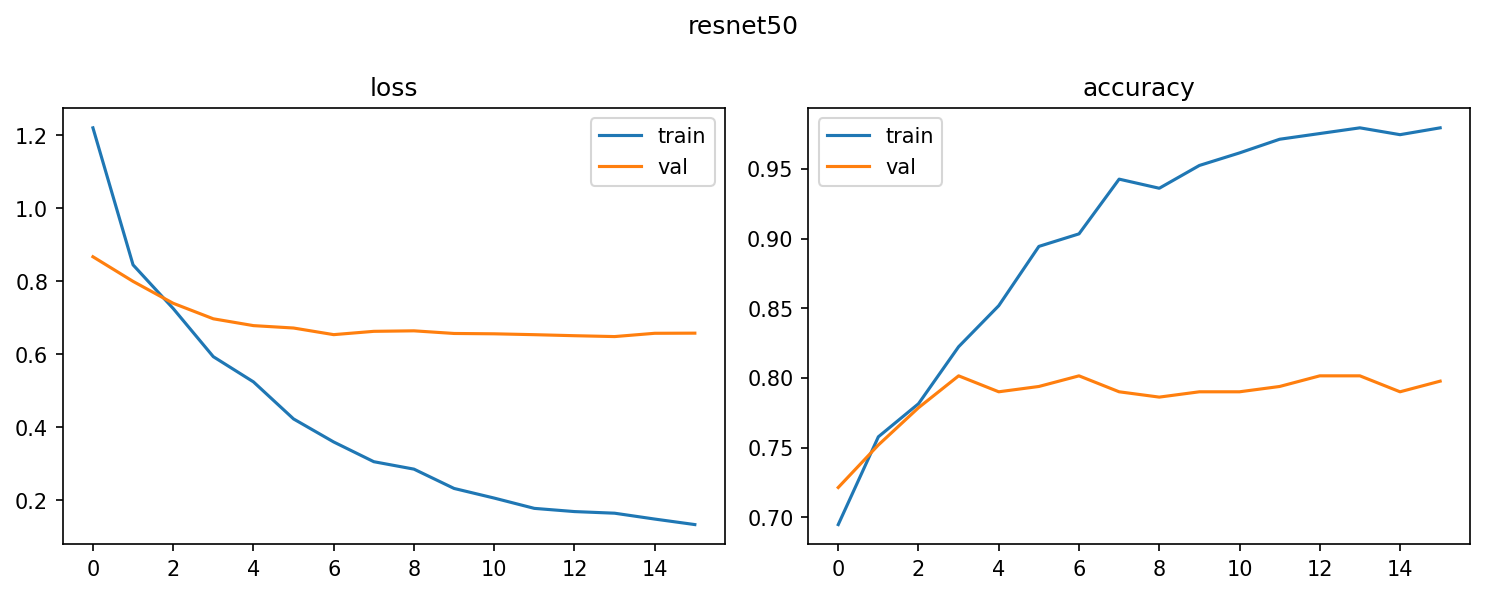

Epoch 1/10



 1/77 ━━━━━━━━━━━━━━━━━━━━ 7:17 6s/step - accuracy: 0.1875 - loss: 2.6815


 3/77 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.1528 - loss: 2.2948


 5/77 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.1548 - loss: 2.2431


 7/77 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.1639 - loss: 2.2264

...


71/77 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9700 - loss: 0.1353


73/77 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9702 - loss: 0.1353


75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9704 - loss: 0.1352


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9706 - loss: 0.1352


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.9771 - loss: 0.1351 - val_accuracy: 0.7901 - val_loss: 0.6723 - learning_rate: 5.0000e-06


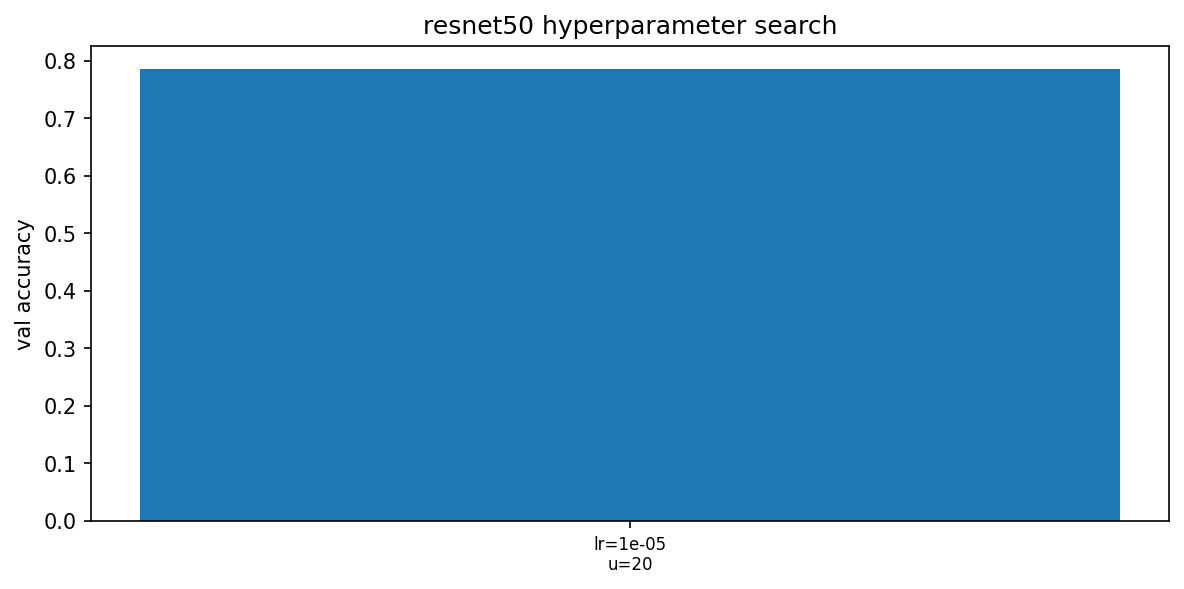

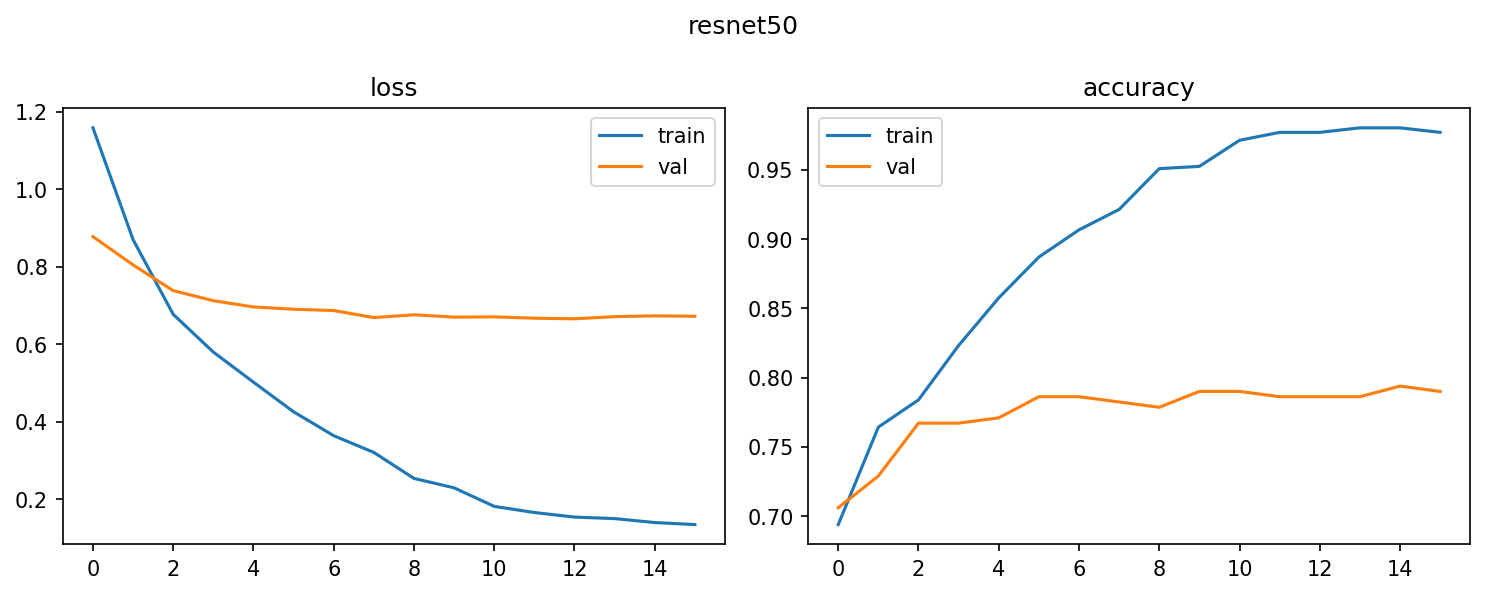

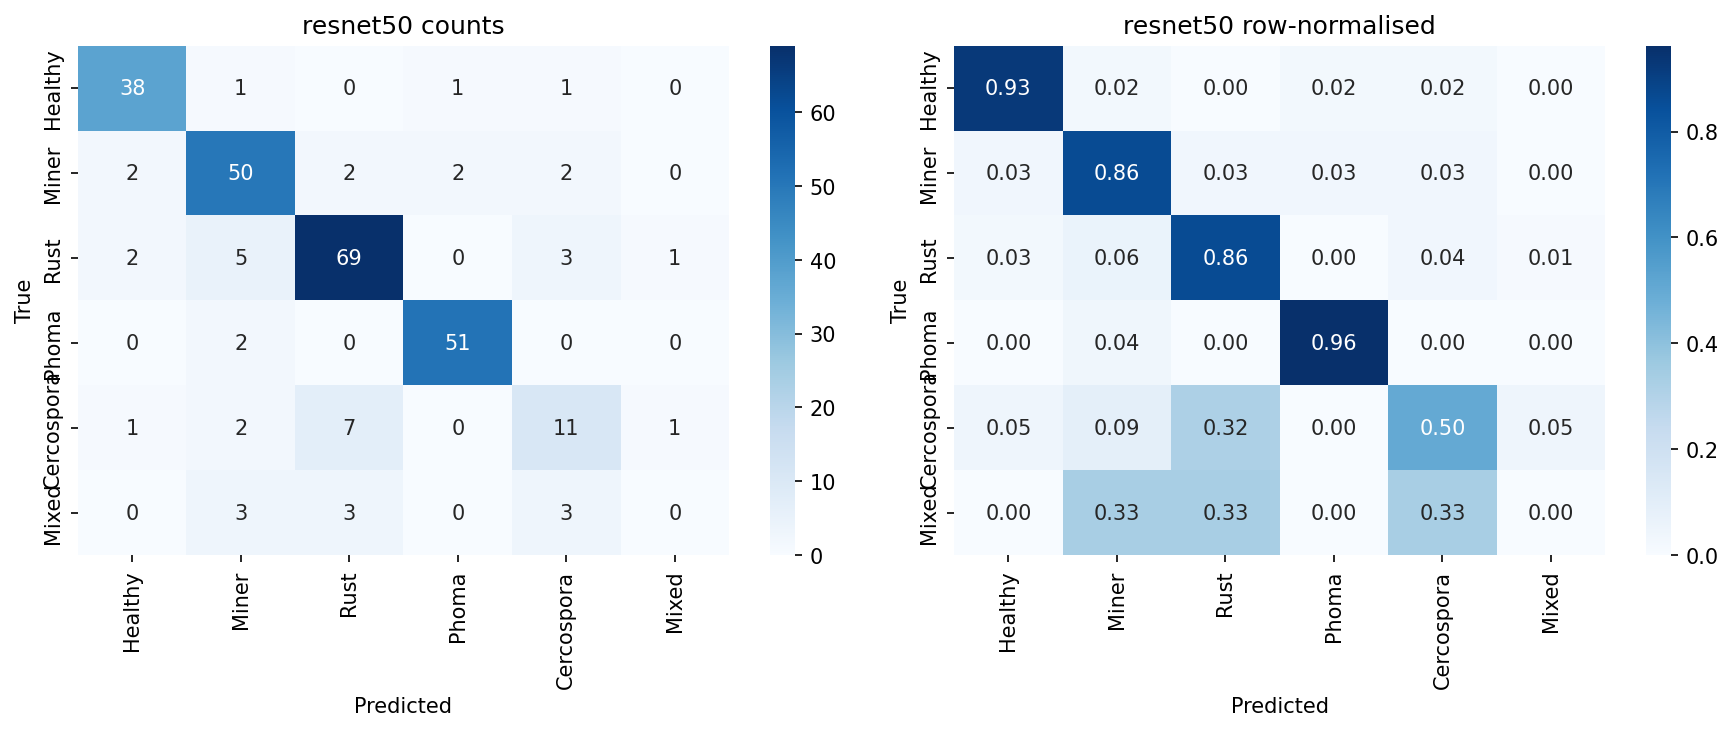

{'model': 'ResNet-50', 'features': 'raw images', 'val_acc': 0.7862595419847328, 'test_acc': 0.8326996197718631, 'macro_f1': 0.677571932457234, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20}}


In [18]:
resnet = ResNetPipeline(
    dataset, split,
    name="resnet50",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=True,
    epochs_head=10,
    epochs_ft=16,
    batch_size=16,
    search_grid=[
        {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20},
    ],
)
resnet.run()
record("ResNet-50", "raw images", resnet)


### 10.3 MixUp on/off ablation on EfficientNet (short run)


Epoch 1/8



 1/77 ━━━━━━━━━━━━━━━━━━━━ 12:43 10s/step - accuracy: 0.2500 - loss: 1.6344


 2/77 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - accuracy: 0.2656 - loss: 1.6796  


 3/77 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.2535 - loss: 1.7062


 4/77 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.2565 - loss: 1.6836

...


65/77 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7832 - loss: 0.8169


68/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7825 - loss: 0.8177


72/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7816 - loss: 0.8189


75/77 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7809 - loss: 0.8197


77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.7635 - loss: 0.8395 - val_accuracy: 0.7557 - val_loss: 0.7395 - learning_rate: 2.5000e-06


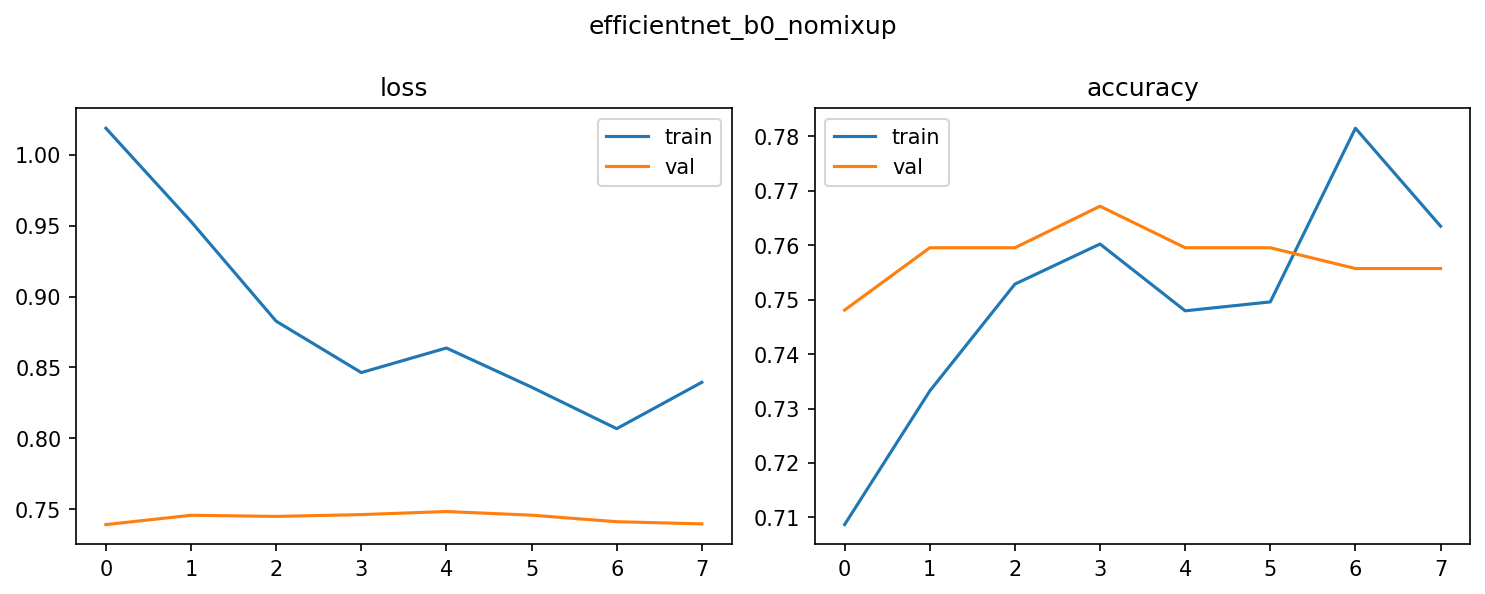

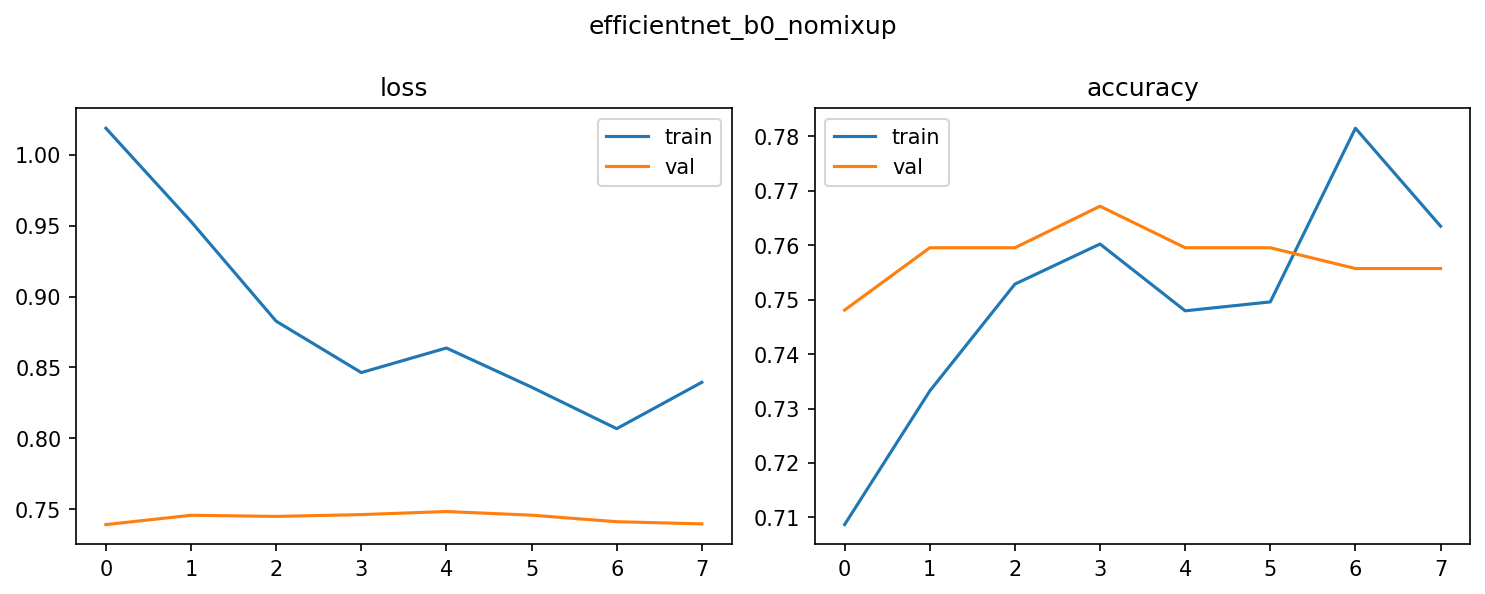

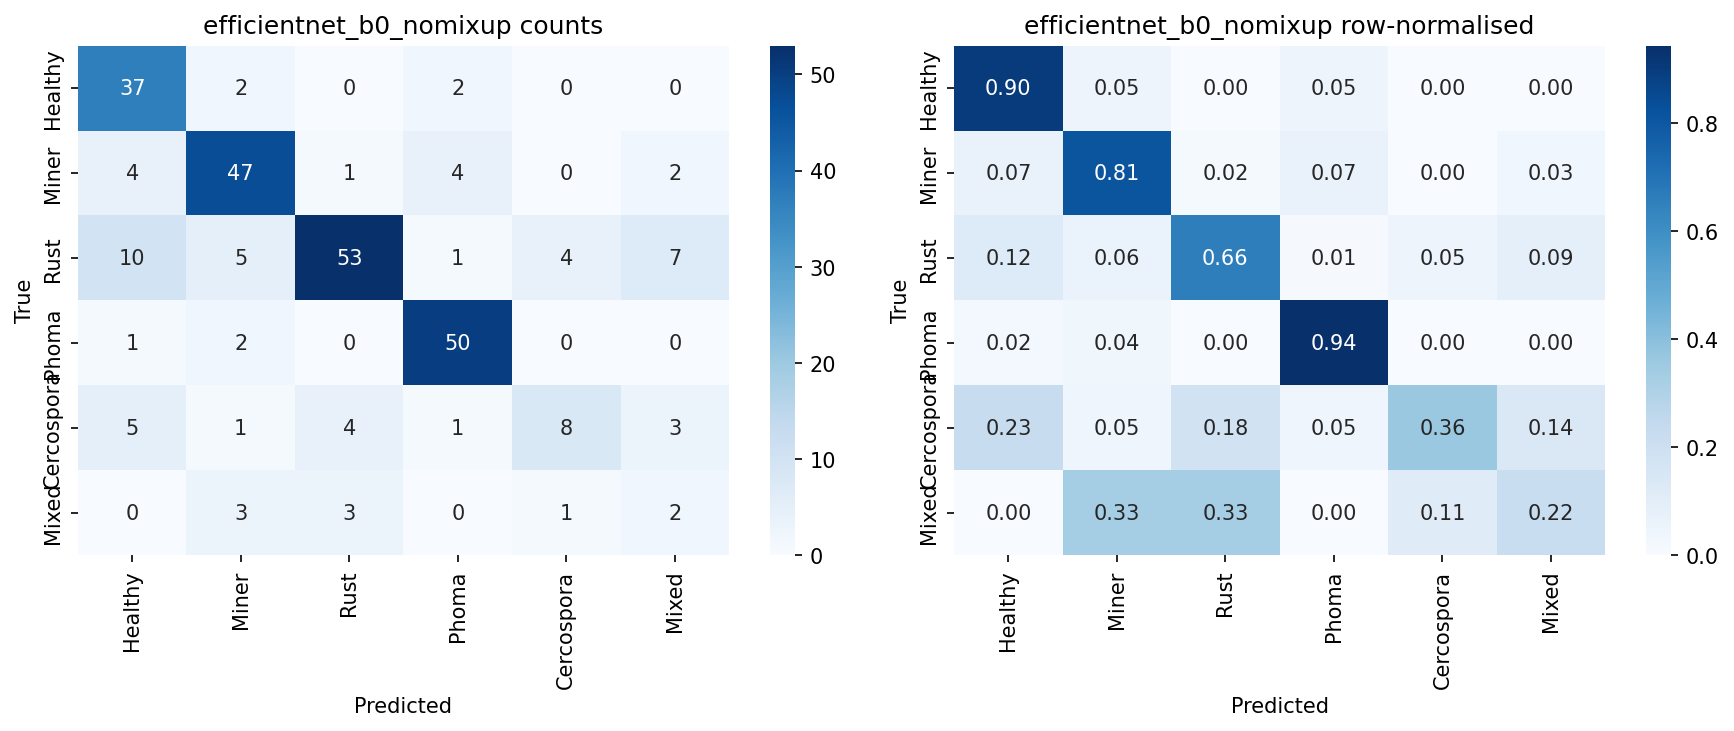

{'model': 'EfficientNet-B0 (no MixUp)', 'features': 'raw images', 'val_acc': 0.7480916030534351, 'test_acc': 0.7490494296577946, 'macro_f1': 0.6392403435792101, 'best_params': {'lr': 1e-05, 'dropout': 0.3, 'unfreeze': 20, 'mixup': False}}


In [19]:
effnet_nomix = EfficientNetPipeline(
    dataset, split,
    name="efficientnet_b0_nomixup",
    results_dir=PATHS["results_dir"],
    figures_dir=PATHS["figures_dir"],
    models_dir=PATHS["models_dir"],
    use_mixup=False,
    epochs_head=8,
    epochs_ft=12,
    batch_size=16,
    search_grid=[{"lr": 1e-5, "dropout": 0.3, "unfreeze": 20}],
)
# Skip a second full search: fit + refit is enough for the ablation row.
effnet_nomix.ingest()
effnet_nomix.fit()
effnet_nomix.best_params = {"lr": 1e-5, "dropout": 0.3, "unfreeze": 20, "mixup": False}
effnet_nomix.refit()
effnet_nomix.test_metrics = effnet_nomix.report(
    effnet_nomix.y_true_test, effnet_nomix.y_pred_test, effnet_nomix.name
)
record("EfficientNet-B0 (no MixUp)", "raw images", effnet_nomix)


### 10.4 Probability ensemble


In [20]:
from sklearn.metrics import accuracy_score, f1_score

proba_svm = svm_deep.proba_test
proba_eff = effnet.proba_test
proba_ens = ensemble_average(proba_svm, proba_eff)
y_ens = np.argmax(proba_ens, axis=1)
y_test = svm_deep.y_true_test
ens_metrics = classification_metrics(y_test, y_ens)
print("Ensemble SVM-deep + EffNet:", ens_metrics)
svm_deep.report(y_test, y_ens, "ensemble_svm_effnet")
record(
    "Ensemble",
    "SVM-deep + EffNet",
    val_acc=None,
    test_acc=ens_metrics["acc"],
    macro_f1=ens_metrics["macro_f1"],
    best_params={"combine": "mean_proba"},
)

if resnet.proba_test is not None:
    proba_3 = ensemble_average(proba_svm, proba_eff, resnet.proba_test)
    y3 = np.argmax(proba_3, axis=1)
    m3 = classification_metrics(y_test, y3)
    print("Ensemble + ResNet:", m3)
    record(
        "Ensemble",
        "SVM-deep + EffNet + ResNet",
        val_acc=None,
        test_acc=m3["acc"],
        macro_f1=m3["macro_f1"],
        best_params={"combine": "mean_proba"},
    )


ValueError: all input arrays must have the same shape

### 10.5 Class-5 residual rule

Official task stays 6-class. Extra variant: a multi-label probe on the four binary disease columns. Predict Mixed if two heads fire above τ, or if the 6-class top-1 vs top-2 gap is below δ. τ and δ are chosen on validation only.


Locked tau, delta: 0.6 0.15
Residual rule val: {'acc': 0.6793893129770993, 'macro_f1': 0.6132519141270345, 'weighted_f1': 0.731877677011727, 'macro_precision': 0.7430409008954703, 'macro_recall': 0.6401433751044768}
Residual rule test: {'acc': 0.6374045801526718, 'macro_f1': 0.5983272645591297, 'weighted_f1': 0.7071811338623702, 'macro_precision': 0.7294799666502266, 'macro_recall': 0.6157341636262997}


{'model': 'SVM-deep + residual rule', 'features': 'deep (frozen EffNet)', 'val_acc': 0.6793893129770993, 'test_acc': 0.6374045801526718, 'macro_f1': 0.5983272645591297, 'best_params': {'tau': 0.6, 'delta': 0.15}}


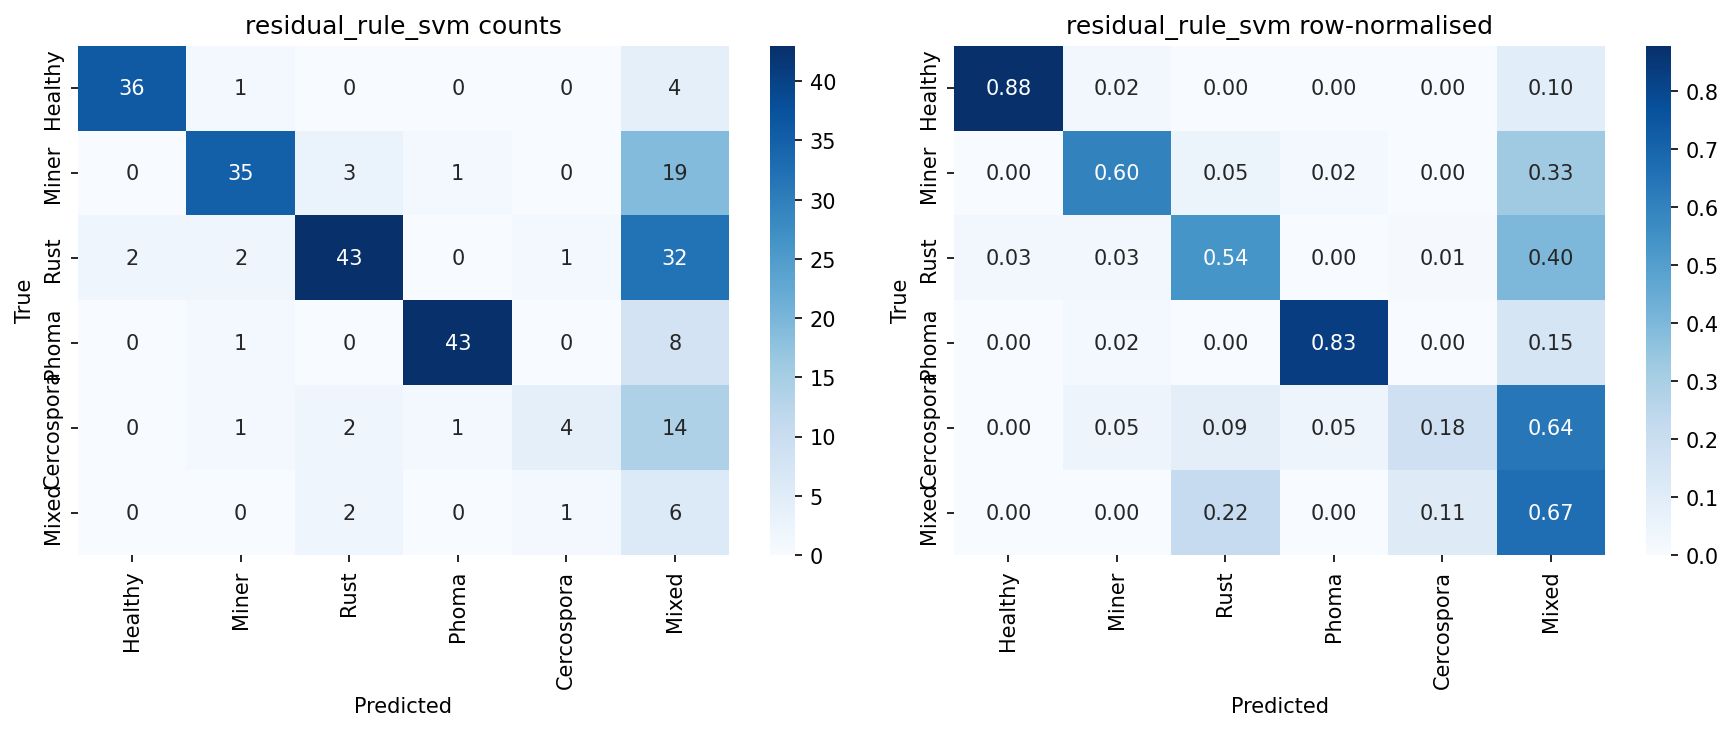

In [21]:
from sklearn.preprocessing import StandardScaler

disease_cols = ["miner", "rust", "phoma", "cercospora"]
Y_all = df[disease_cols].values.astype(np.int32)
Y_train = Y_all[split.train_idx]
Y_val = Y_all[split.val_idx]
Y_test = Y_all[split.test_idx]

# Probe on scaled frozen embeddings (already extracted, no extra CNN).
sc = StandardScaler()
Ztr = sc.fit_transform(pack_deep.X_train)
Zva = sc.transform(pack_deep.X_val)
Zte = sc.transform(pack_deep.X_test)

disease_val = fit_disease_probe(Ztr, Y_train, Zva)
disease_test = fit_disease_probe(Ztr, Y_train, Zte)

proba_val = svm_deep.model.predict_proba(svm_deep.scaled.X_val)
proba_test = svm_deep.proba_test

rule = ResidualMixedRule()
tau, delta = rule.search(pack_deep.y_val, proba_val, disease_val)
print("Locked tau, delta:", tau, delta)

y_rule_val = rule.predict(proba_val, disease_val)
y_rule_test = rule.predict(proba_test, disease_test)
rule_val = classification_metrics(pack_deep.y_val, y_rule_val)
rule_test = classification_metrics(pack_deep.y_test, y_rule_test)
print("Residual rule val:", rule_val)
print("Residual rule test:", rule_test)
svm_deep.report(pack_deep.y_test, y_rule_test, "residual_rule_svm")
record(
    "SVM-deep + residual rule",
    "deep (frozen EffNet)",
    val_acc=rule_val["acc"],
    test_acc=rule_test["acc"],
    macro_f1=rule_test["macro_f1"],
    best_params={"tau": tau, "delta": delta},
)


## 11. BRACOL YOLO cross-check

YOLO class ids are **not** the same as `predominant_stress`. Mapping: Cercospora=0→4, Miner=1→1, Phoma=2→3, Rust=3→2. Filenames look like `1_jpg.rf.{hash}.txt`.


BRACOL images with labels: 1744
Compared: 262 agreement: 0.6984732824427481
Errors where YOLO has multiple lesion types: 20


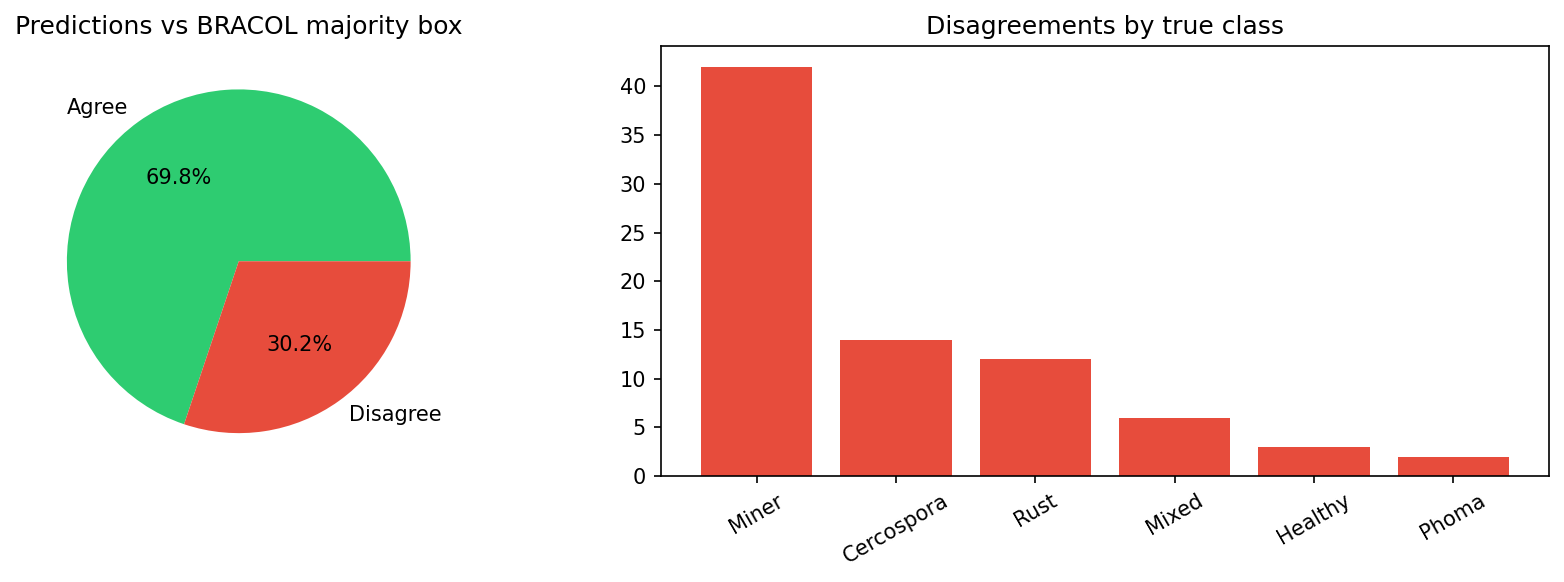

In [22]:
bracol = load_bracol_labels(PATHS["bracol_dir"])
print("BRACOL images with labels:", len(bracol))

test_ids = df.iloc[split.test_idx]["id"].values
best_preds = y_ens if "y_ens" in dir() else svm_deep.y_pred_test
y_true = svm_deep.y_true_test

rows_cmp = []
for i, img_id in enumerate(test_ids):
    if img_id not in bracol:
        continue
    dets = bracol[img_id]
    if len(dets) == 0:
        bracol_lab = 0
    else:
        most = max(set(dets), key=dets.count)
        bracol_lab = BRACOL_TO_STRESS.get(most, -1)
    rows_cmp.append({
        "id": int(img_id),
        "true": STRESS_NAMES.get(int(y_true[i]), str(y_true[i])),
        "ours": STRESS_NAMES.get(int(best_preds[i]), str(best_preds[i])),
        "bracol": STRESS_NAMES.get(int(bracol_lab), str(bracol_lab)),
        "n_det": len(dets),
        "multi_lesion": len(set(dets)) > 1,
        "agree": int(bracol_lab == best_preds[i]),
    })

comp = pd.DataFrame(rows_cmp)
if len(comp):
    print("Compared:", len(comp), "agreement:", float(comp["agree"].mean()))
    print("Errors where YOLO has multiple lesion types:",
          int(((comp["agree"] == 0) & comp["multi_lesion"]).sum()))
    comp.to_csv(os.path.join(PATHS["results_dir"], "bracol_crosscheck.csv"), index=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].pie(
        [comp["agree"].sum(), (1 - comp["agree"]).sum()],
        labels=["Agree", "Disagree"], autopct="%1.1f%%",
        colors=["#2ecc71", "#e74c3c"],
    )
    axes[0].set_title("Predictions vs BRACOL majority box")
    disagree = comp[comp["agree"] == 0]
    if len(disagree):
        vc = disagree["true"].value_counts()
        axes[1].bar(vc.index.astype(str), vc.values, color="#e74c3c")
        axes[1].tick_params(axis="x", rotation=30)
        axes[1].set_title("Disagreements by true class")
    fig.tight_layout()
    save_and_show(fig, "bracol_crosscheck.png", PATHS["figures_dir"])
else:
    print("No overlap with BRACOL labels. Folder missing or different filenames.")


## 12. Final results table and literature

Esgario et al. (2020), *Computers and Electronics in Agriculture*:

- Leaf **classification** set: 1,685 images, **five** classes (they dropped 62 mixed-equal leaves).
- Split: 70 / 15 / 15 (not 5-fold).
- ResNet50 single-task **95.63%** accuracy; multi-task **95.24%**, precision 95.29%, recall 91.14%.
- They crop the leaf with an HSV-S threshold before 224×224.

This notebook is the **6-class official** run (Mixed kept, 1,747 images). Dataset load is complete: every CSV row has a JPEG. A matched 5-class protocol is `P1_no_mixed_notebook.ipynb`. Remaining gap vs 95.63% is protocol / split / crop, not missing files.


                     model                   features  val_acc  test_acc  macro_f1                                                   best_params
                       SVM                handcrafted 0.645038  0.622137  0.470436              {'kernel': 'linear', 'C': 0.1, 'gamma': 'scale'}
                       SVM       deep (frozen EffNet) 0.828244  0.820611  0.697977                  {'kernel': 'rbf', 'C': 100, 'gamma': 0.0001}
     SVM-linear (ablation)       deep (frozen EffNet) 0.820611  0.805344  0.683780                                {'kernel': 'linear', 'C': 0.1}
                       SVM               deep PCA-256 0.797710  0.790076  0.609060                  {'kernel': 'rbf', 'C': 10, 'gamma': 'scale'}
           EfficientNet-B0                 raw images 0.782443  0.767176  0.651728                {'lr': 0.0001, 'dropout': 0.3, 'unfreeze': 20}
                   XGBoost                handcrafted 0.778626  0.782443  0.600455  {'n_estimators': 200, 'max_depth': 5, 'learnin

'/mnt/c/Users/Alecs/PML/Project_1/figures/final_accuracy_bars.png'

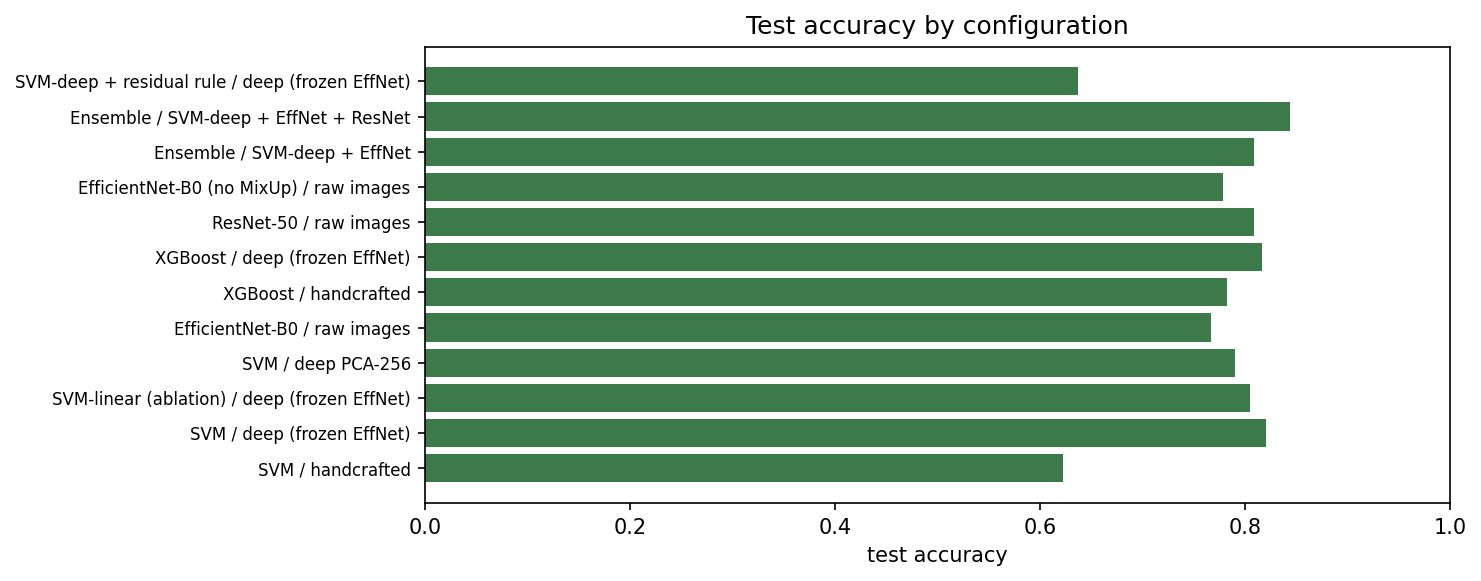

In [23]:
results_df = pd.DataFrame(results_rows())
results_df.to_csv(os.path.join(PATHS["results_dir"], "final_results.csv"), index=False)
print(results_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
plot_df = results_df.dropna(subset=["test_acc"]).copy()
labels = plot_df["model"] + " / " + plot_df["features"]
ax.barh(range(len(plot_df)), plot_df["test_acc"], color="#3d7a4a")
ax.set_yticks(range(len(plot_df)))
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("test accuracy")
ax.set_xlim(0, 1)
ax.set_title("Test accuracy by configuration")
fig.tight_layout()
save_and_show(fig, "final_accuracy_bars.png", PATHS["figures_dir"])


## 13. Conclusions

- Two representations (handcrafted vs frozen CNN embeddings) and two official models (SVM, EfficientNet) are implemented end to end, each with its own ingest → fit → search → refit → report loop.
- The split is shared. Test is not used to pick hyperparameters.
- Mixed (class 5) is kept. The residual rule is an extra, not a replacement of the official 6-class task.
- ResNet-50 is the designated third method and the closest architecture family to Esgario et al. Numbers in this notebook are not directly comparable (6 vs 5 classes). See `P1_no_mixed_notebook.ipynb` for the 5-class protocol.
- MixUp follows Esgario's augmentation experiments; it is not presented as a new idea.

Next cell writes a compact JSON of the run so the report can copy numbers without re-typing them.


In [2]:
payload = {
    "n_csv": summary["n_csv"],
    "n_kept": summary["n_kept"],
    "drop_mixed": summary["drop_mixed"],
    "split": split.sizes(),
    "results": results_rows(),
}
with open(os.path.join(PATHS["results_dir"], "run_summary.json"), "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, default=str)
print("Wrote results/run_summary.json")


NameError: name 'summary' is not defined